# Custom statistics for KeypointMoseq Output

Comput statistics from the stats_df.csv file. 

Load it and plot boxplots for every syllable and every variable (frequency, duration and occupancy)

In [2]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as smm
import plotly.express as px
import matplotlib.colors as mcolors

def plot_boxplots_with_points(df, global_df, variables, out_dir, alpha=0.05,
                              colorscale_name="Temps"):
    """
    Boxplots + jittered individual points.
    Colors come from a Plotly colormap (Temps, Geyser, etc.).
    """

    # --- build Matplotlib colormap from Plotly ---
    plotly_colors = px.colors.get_colorscale(colorscale_name)

    def _plotly_to_mpl_colors(colorscale):
        """
        Convert Plotly colorscale entries to Matplotlib-friendly RGB tuples or hex.
        colorscale: list like [[pos, 'rgb(r,g,b)'], [pos, '#RRGGBB'], ...]
        """
        mpl_colors = []
        for pos, col in colorscale:
            col = col.strip()
            if col.startswith("rgb"):
                # parse 'rgb(r,g,b)'
                inside = col[col.find("(")+1 : col.find(")")]
                parts = [p.strip() for p in inside.split(",")]
                r, g, b = [int(p) for p in parts]
                mpl_colors.append((r/255.0, g/255.0, b/255.0))
            else:
                # assume already hex or named color
                mpl_colors.append(col)
        return mpl_colors

    mpl_colors_list = _plotly_to_mpl_colors(plotly_colors)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        colorscale_name, mpl_colors_list, N=256
    )

    groups = sorted(df["group"].unique())
    syllables = sorted(df["syllable"].unique())

    # pick N evenly spaced colors from cmap
    group_colors = [cmap(i) for i in np.linspace(0, 1, len(groups))]

    for var in variables:
        fig, ax = plt.subplots(
            figsize=(max(10, len(syllables)*0.6), 6), constrained_layout=True
        )

        positions = np.arange(len(syllables))
        width = 0.15
        offsets = np.linspace(-1.5*width, 1.5*width, len(groups))

        # ---------- boxplots + dots ----------
        for gi, g in enumerate(groups):
            xs = []
            data = []

            for i, syl in enumerate(syllables):
                vals = df.loc[
                    (df["group"] == g) & (df["syllable"] == syl),
                    var
                ].dropna()
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                xs.append(positions[i] + offsets[gi])

            # boxplot
            if data:
                bp = ax.boxplot(
                    data,
                    positions=xs,
                    widths=width,
                    patch_artist=True,
                    showfliers=False,
                )
                for box in bp["boxes"]:
                    box.set_facecolor(group_colors[gi])
                    box.set_alpha(0.5)

            # jittered individual points
            for i, syl in enumerate(syllables):
                vals = df.loc[
                    (df["group"] == g) & (df["syllable"] == syl),
                    var
                ].dropna().values
                if len(vals) == 0:
                    continue

                jitter = np.random.normal(scale=0.02, size=len(vals))
                xpts = positions[i] + offsets[gi] + jitter

                ax.scatter(
                    xpts, vals,
                    color=group_colors[gi],
                    edgecolor="black",
                    s=15,
                    alpha=0.8,
                    linewidth=0.3,
                )

        # ---------- add significance '*' ----------
        sig_syls = set(
            global_df[
                (global_df["variable"] == var) & (global_df["pval"] < alpha)
            ]["syllable"]
        )

        if len(df[var].dropna()) > 0:
            y_min = df[var].min()
            y_max = df[var].max()
            y_range = (y_max - y_min) if y_max > y_min else 1
        else:
            y_min, y_max, y_range = 0, 1, 1

        for syl in sig_syls:
            i = syllables.index(syl)
            y_text = df[df["syllable"] == syl][var].max() + 0.07 * y_range
            ax.text(
                positions[i],
                y_text,
                "*",
                ha="center",
                va="bottom",
                fontsize=18,
                color="black"
            )

        # ---- labels ----
        ax.set_xticks(positions)
        ax.set_xticklabels(syllables)
        ax.set_xlabel("Syllable")
        ax.set_ylabel(var)
        ax.set_title(
            f"{var.capitalize()} by group and syllable\n"
            f"('*' = global effect p < {alpha})"
        )

        # legend
        handles = [
            plt.Line2D([0], [0], color=group_colors[i], lw=6)
            for i in range(len(groups))
        ]
        ax.legend(handles, groups, title="Group", loc="best")

        # save
        fig_path = os.path.join(out_dir, f"boxplot_{var}_with_points.svg")
        fig.savefig(fig_path, dpi=300)
        plt.close(fig)
        print(f"Saved: {fig_path}")
def run_syllable_stats(
    csv_path: str,
    out_dir: str = "stats_results",
    variables=("frequency", "duration"),
    alpha: float = 0.05,
    syll_info_path: str | None = None,
    colorscale_name: str = "Temps",
):
    """
    Run normality tests, ANOVA / Kruskal, post-hoc comparisons and boxplots
    for given variables in stats_df.csv.

    Expected columns in csv:
        - 'group'    : 4 groups (e.g., group..group4)
        - 'syllable' : integer syllable ID
        - 'frequency', 'duration' : variables to analyze
        - 'name'     : subject / file ID (one row per [name, syllable])

    Optionally merges syllable info from syll_info_path (must contain 'syllable').

    Saves:
        out_dir/global_tests.csv
        out_dir/posthoc_tests.csv
        out_dir/boxplot_<variable>_with_points.svg
    """
    os.makedirs(out_dir, exist_ok=True)

    # ---------------- load main data ----------------
    df = pd.read_csv(csv_path)

    groups = sorted(df["group"].unique())
    syllables = sorted(df["syllable"].unique())

    global_rows = []
    posthoc_rows = []

    # ---------------- how many animals per group ----------------
    print("\n=== Animals per group ===")
    animal_counts = (
        df.groupby("group")["name"]
        .nunique()        # count unique animals in each group
        .sort_index()
    )
    print(animal_counts.to_string())
    print("=========================\n")
    # ---------------- global tests (ANOVA / Kruskal) ----------------
    for var in variables:
        for syl in syllables:
            sub = df[df["syllable"] == syl]

            # --- normality test per group (Shapiro) ---
            normal_by_group = {}
            data_by_group = []
            for g in groups:
                vals = sub.loc[sub["group"] == g, var].dropna().values
                data_by_group.append(vals)

                if len(vals) >= 3:
                    stat_sw, p_sw = stats.shapiro(vals)
                    normal_by_group[g] = bool(p_sw > alpha)
                else:
                    # too few samples to test, treat as non-normal
                    normal_by_group[g] = False

            valid_groups = [g for g, vals in zip(groups, data_by_group) if len(vals) > 0]

            if len(valid_groups) < 2:
                test = "insufficient"
                stat_val = np.nan
                p_val = np.nan
            else:
                all_normal = all(normal_by_group[g] for g in groups)

                if all_normal:
                    # --- one-way ANOVA ---
                    test = "ANOVA"
                    try:
                        stat_val, p_val = stats.f_oneway(
                            *[
                                sub.loc[sub["group"] == g, var]
                                .dropna()
                                .values
                                for g in groups
                            ]
                        )
                    except Exception:
                        test = "ANOVA_error"
                        stat_val, p_val = np.nan, np.nan
                else:
                    # --- Kruskal-Wallis (non-parametric ANOVA equivalent) ---
                    test = "Kruskal"
                    try:
                        stat_val, p_val = stats.kruskal(
                            *[
                                sub.loc[sub["group"] == g, var]
                                .dropna()
                                .values
                                for g in groups
                            ]
                        )
                    except Exception:
                        test = "Kruskal_error"
                        stat_val, p_val = np.nan, np.nan

            row = {
                "variable": var,
                "syllable": syl,
                "test": test,
                "stat": stat_val,
                "pval": p_val,
            }
            for g in groups:
                row[f"normal_{g}"] = normal_by_group[g]

            global_rows.append(row)

    global_df = pd.DataFrame(global_rows)

    # ---------------- post-hoc multiple comparisons ----------------
    for var in variables:
        for syl in syllables:
            g_row = global_df[
                (global_df["variable"] == var) & (global_df["syllable"] == syl)
            ].iloc[0]

            if not np.isfinite(g_row["pval"]) or g_row["pval"] >= alpha:
                continue

            test_type = g_row["test"]
            sub = df[df["syllable"] == syl]
            pair_results = []

            for g1, g2 in combinations(groups, 2):
                x1 = sub.loc[sub["group"] == g1, var].dropna().values
                x2 = sub.loc[sub["group"] == g2, var].dropna().values

                if len(x1) == 0 or len(x2) == 0:
                    continue

                if test_type.startswith("ANOVA"):
                    # Welch's t-test
                    stat_val, p_pair = stats.ttest_ind(
                        x1, x2, equal_var=False, nan_policy="omit"
                    )
                    stat_name = "t"
                else:
                    # Mann-Whitney U for non-parametric case
                    stat_val, p_pair = stats.mannwhitneyu(
                        x1, x2, alternative="two-sided"
                    )
                    stat_name = "U"

                pair_results.append(
                    {
                        "variable": var,
                        "syllable": syl,
                        "global_test": test_type,
                        "group": g1,
                        "group2": g2,
                        "stat_name": stat_name,
                        "stat": stat_val,
                        "p_uncorrected": p_pair,
                    }
                )

            if not pair_results:
                continue

            # FDR-BH correction within this syllable+variable
            pvals = [r["p_uncorrected"] for r in pair_results]
            reject, p_adj, _, _ = smm.multipletests(
                pvals, alpha=alpha, method="fdr_bh"
            )

            for r, p_corr, rej in zip(pair_results, p_adj, reject):
                r["p_adj"] = p_corr
                r["significant"] = bool(rej)
                posthoc_rows.append(r)

    posthoc_df = pd.DataFrame(posthoc_rows)

    # ---------------- merge syll_info if provided ----------------
    if syll_info_path is not None and os.path.exists(syll_info_path):
        syll_info = pd.read_csv(syll_info_path)
        if "syllable" in syll_info.columns:
            # merge into global and posthoc tables
            global_df = global_df.merge(syll_info, on="syllable", how="left")
            posthoc_df = posthoc_df.merge(syll_info, on="syllable", how="left")
            print(f"Merged syll_info from: {syll_info_path}")
        else:
            print("Warning: syll_info.csv does not contain a 'syllable' column. Skipping merge.")

    # ---------------- save tables ----------------
    global_path = os.path.join(out_dir, "global_tests.csv")
    posthoc_path = os.path.join(out_dir, "posthoc_tests.csv")
    global_df.to_csv(global_path, index=False)
    posthoc_df.to_csv(posthoc_path, index=False)
    print(f"Saved global tests to:   {global_path}")
    print(f"Saved post-hoc tests to: {posthoc_path}")

    # ---------------- plots (boxplots + points) ----------------
    plot_boxplots_with_points(
        df=df,
        global_df=global_df,
        variables=variables,
        out_dir=out_dir,
        alpha=alpha,
        colorscale_name=colorscale_name,
    )

    return global_df, posthoc_df

# if __name__ == "__main__":
#     # Adjust these paths as needed
#     csv_path = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/stats/stats_df.csv'
#     out_dir = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/stats"
#     syll_info_path = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/syll_info.csv"  # <-- update or None

#     global_df, posthoc_df = run_syllable_stats(
#         csv_path,
#         out_dir=out_dir,
#         variables=("frequency", "duration", "occupancy"),
#         alpha=0.05,
#         syll_info_path=syll_info_path,
#         colorscale_name="Temps",   # or "Geyser"
#     )

In [ ]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as smm
import plotly.express as px
import matplotlib.colors as mcolors


def plot_boxplots_with_points(
    df,
    global_df,
    variables,
    out_dir,
    alpha=0.05,
    colorscale_name="Temps",
    group_col="group",
):
    """
    Boxplots + jittered individual points.
    Colors come from a Plotly colormap (Temps, Geyser, etc.).
    """

    # ---- auto-detect group column if needed ----
    if group_col not in df.columns:
        if "group1" in df.columns:
            group_col = "group1"
        else:
            raise KeyError(
                f"Could not find group column '{group_col}' in df. "
                f"Available columns: {list(df.columns)}"
            )

    # --- build Matplotlib colormap from Plotly ---
    plotly_colors = px.colors.get_colorscale(colorscale_name)

    def _plotly_to_mpl_colors(colorscale):
        mpl_colors = []
        for pos, col in colorscale:
            col = col.strip()
            if col.startswith("rgb"):
                inside = col[col.find("(") + 1 : col.find(")")]
                parts = [p.strip() for p in inside.split(",")]
                r, g, b = [int(p) for p in parts]
                mpl_colors.append((r / 255.0, g / 255.0, b / 255.0))
            else:
                mpl_colors.append(col)
        return mpl_colors

    mpl_colors_list = _plotly_to_mpl_colors(plotly_colors)
    cmap = mcolors.LinearSegmentedColormap.from_list(colorscale_name, mpl_colors_list, N=256)

    groups = sorted(df[group_col].dropna().unique())
    syllables = sorted(df["syllable"].dropna().unique())

    group_colors = [cmap(i) for i in np.linspace(0, 1, len(groups))]

    for var in variables:
        fig, ax = plt.subplots(
            figsize=(max(10, len(syllables) * 0.6), 6),
            constrained_layout=True,
        )

        positions = np.arange(len(syllables))
        width = 0.15
        offsets = np.linspace(-1.5 * width, 1.5 * width, len(groups))

        # ---------- boxplots + dots ----------
        for gi, g in enumerate(groups):
            xs = []
            data = []

            for i, syl in enumerate(syllables):
                vals = df.loc[(df[group_col] == g) & (df["syllable"] == syl), var].dropna()
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                xs.append(positions[i] + offsets[gi])

            if data:
                bp = ax.boxplot(
                    data,
                    positions=xs,
                    widths=width,
                    patch_artist=True,
                    showfliers=False,
                )
                for box in bp["boxes"]:
                    box.set_facecolor(group_colors[gi])
                    box.set_alpha(0.5)

            for i, syl in enumerate(syllables):
                vals = df.loc[(df[group_col] == g) & (df["syllable"] == syl), var].dropna().values
                if len(vals) == 0:
                    continue
                jitter = np.random.normal(scale=0.02, size=len(vals))
                xpts = positions[i] + offsets[gi] + jitter
                ax.scatter(
                    xpts,
                    vals,
                    color=group_colors[gi],
                    edgecolor="black",
                    s=15,
                    alpha=0.8,
                    linewidth=0.3,
                )

        # ---------- add significance '*' ----------
        sig_syls = set(
            global_df[(global_df["variable"] == var) & (global_df["pval"] < alpha)]["syllable"]
        )

        if len(df[var].dropna()) > 0:
            y_min = df[var].min()
            y_max = df[var].max()
            y_range = (y_max - y_min) if y_max > y_min else 1
        else:
            y_range = 1

        for syl in sig_syls:
            if syl not in syllables:
                continue
            i = syllables.index(syl)
            y_text = df[df["syllable"] == syl][var].max() + 0.07 * y_range
            ax.text(positions[i], y_text, "*", ha="center", va="bottom", fontsize=18, color="black")

        ax.set_xticks(positions)
        ax.set_xticklabels(syllables)
        ax.set_xlabel("Syllable")
        ax.set_ylabel(var)
        ax.set_title(f"{var.capitalize()} by group and syllable\n('*' = global effect p < {alpha})")

        handles = [plt.Line2D([0], [0], color=group_colors[i], lw=6) for i in range(len(groups))]
        ax.legend(handles, groups, title="Group", loc="best")

        fig_path = os.path.join(out_dir, f"boxplot_{var}_with_points.svg")
        fig.savefig(fig_path, dpi=300)
        plt.close(fig)
        print(f"Saved: {fig_path}")


def run_syllable_stats(
    csv_path: str,
    out_dir: str = "stats_results",
    variables=("frequency", "duration"),
    alpha: float = 0.05,
    syll_info_path: str | None = None,
    colorscale_name: str = "Temps",
    group_col: str = "group",   # <-- NEW
):
    """
    Run normality tests, ANOVA / Kruskal, post-hoc comparisons and boxplots.

    Required columns:
        - group_col (default 'group', but your file uses 'group1')
        - 'syllable'
        - variables (e.g. 'frequency', 'duration', 'occupancy')
        - 'name'
    """
    os.makedirs(out_dir, exist_ok=True)
    df = pd.read_csv(csv_path)

    # ---- auto-detect group column if needed ----
    if group_col not in df.columns:
        if "group1" in df.columns:
            group_col = "group1"
            print(f"[Info] Using group_col='group1' (because 'group' not found).")
        else:
            raise KeyError(
                f"Could not find group column '{group_col}' in CSV. "
                f"Available columns: {list(df.columns)}"
            )

    groups = sorted(df[group_col].dropna().unique())
    syllables = sorted(df["syllable"].dropna().unique())

    print("\n=== Animals per group ===")
    animal_counts = df.groupby(group_col)["name"].nunique().sort_index()
    print(animal_counts.to_string())
    print("=========================\n")

    global_rows = []
    posthoc_rows = []

    # ---------------- global tests (ANOVA / Kruskal) ----------------
    for var in variables:
        for syl in syllables:
            sub = df[df["syllable"] == syl]

            normal_by_group = {}
            data_by_group = []
            for g in groups:
                vals = sub.loc[sub[group_col] == g, var].dropna().values
                data_by_group.append(vals)

                if len(vals) >= 3:
                    _, p_sw = stats.shapiro(vals)
                    normal_by_group[g] = bool(p_sw > alpha)
                else:
                    normal_by_group[g] = False

            valid_groups = [g for g, vals in zip(groups, data_by_group) if len(vals) > 0]

            if len(valid_groups) < 2:
                test, stat_val, p_val = "insufficient", np.nan, np.nan
            else:
                all_normal = all(normal_by_group[g] for g in groups)

                if all_normal:
                    test = "ANOVA"
                    try:
                        stat_val, p_val = stats.f_oneway(
                            *[sub.loc[sub[group_col] == g, var].dropna().values for g in groups]
                        )
                    except Exception:
                        test, stat_val, p_val = "ANOVA_error", np.nan, np.nan
                else:
                    test = "Kruskal"
                    try:
                        stat_val, p_val = stats.kruskal(
                            *[sub.loc[sub[group_col] == g, var].dropna().values for g in groups]
                        )
                    except Exception:
                        test, stat_val, p_val = "Kruskal_error", np.nan, np.nan

            row = {"variable": var, "syllable": syl, "test": test, "stat": stat_val, "pval": p_val}
            for g in groups:
                row[f"normal_{g}"] = normal_by_group[g]
            global_rows.append(row)

    global_df = pd.DataFrame(global_rows)

    # ---------------- post-hoc multiple comparisons ----------------
    for var in variables:
        for syl in syllables:
            g_row = global_df[(global_df["variable"] == var) & (global_df["syllable"] == syl)].iloc[0]
            if not np.isfinite(g_row["pval"]) or g_row["pval"] >= alpha:
                continue

            test_type = g_row["test"]
            sub = df[df["syllable"] == syl]
            pair_results = []

            for g1, g2 in combinations(groups, 2):
                x1 = sub.loc[sub[group_col] == g1, var].dropna().values
                x2 = sub.loc[sub[group_col] == g2, var].dropna().values
                if len(x1) == 0 or len(x2) == 0:
                    continue

                if test_type.startswith("ANOVA"):
                    stat_val, p_pair = stats.ttest_ind(x1, x2, equal_var=False, nan_policy="omit")
                    stat_name = "t"
                else:
                    stat_val, p_pair = stats.mannwhitneyu(x1, x2, alternative="two-sided")
                    stat_name = "U"

                pair_results.append(
                    dict(
                        variable=var,
                        syllable=syl,
                        global_test=test_type,
                        group1=g1,
                        group2=g2,
                        stat_name=stat_name,
                        stat=stat_val,
                        p_uncorrected=p_pair,
                    )
                )

            if not pair_results:
                continue

            pvals = [r["p_uncorrected"] for r in pair_results]
            reject, p_adj, _, _ = smm.multipletests(pvals, alpha=alpha, method="fdr_bh")

            for r, p_corr, rej in zip(pair_results, p_adj, reject):
                r["p_adj"] = p_corr
                r["significant"] = bool(rej)
                posthoc_rows.append(r)

    posthoc_df = pd.DataFrame(posthoc_rows)

    # ---------------- merge syll_info if provided ----------------
    if syll_info_path is not None and os.path.exists(syll_info_path):
        syll_info = pd.read_csv(syll_info_path)
        if "syllable" in syll_info.columns:
            global_df = global_df.merge(syll_info, on="syllable", how="left")
            posthoc_df = posthoc_df.merge(syll_info, on="syllable", how="left")
            print(f"Merged syll_info from: {syll_info_path}")
        else:
            print("Warning: syll_info.csv has no 'syllable' column. Skipping merge.")

    # ---------------- save tables ----------------
    global_path = os.path.join(out_dir, "global_tests.csv")
    posthoc_path = os.path.join(out_dir, "posthoc_tests.csv")
    global_df.to_csv(global_path, index=False)
    posthoc_df.to_csv(posthoc_path, index=False)
    print(f"Saved global tests to:   {global_path}")
    print(f"Saved post-hoc tests to: {posthoc_path}")

    # ---------------- plots ----------------
    plot_boxplots_with_points(
        df=df,
        global_df=global_df,
        variables=variables,
        out_dir=out_dir,
        alpha=alpha,
        colorscale_name=colorscale_name,
        group_col=group_col,
    )

    return global_df, posthoc_df


if __name__ == "__main__":
    csv_path = "/Users/annateruel/Desktop/wanhui/stats_df.csv"
    out_dir = "/Users/annateruel/Desktop/stats_results"
    syll_info_path = "/Users/annateruel/Desktop/syll_info.csv"  # or None

    global_df, posthoc_df = run_syllable_stats(
        csv_path,
        out_dir=out_dir,
        variables=("frequency", "duration", "occupancy"),
        alpha=0.05,
        syll_info_path=syll_info_path,
        colorscale_name="Temps",
        group_col="group1",   # <-- IMPORTANT for your file
    )

Plot each individual syllable, on a sepparate boxplot. 

In [4]:
def _build_mpl_cmap_from_plotly(colorscale_name: str, N: int = 256):
    """Build a Matplotlib colormap from a Plotly colorscale name."""
    plotly_colors = px.colors.get_colorscale(colorscale_name)

    mpl_colors = []
    for _, col in plotly_colors:
        col = col.strip()
        if col.startswith("rgb"):
            inside = col[col.find("(") + 1 : col.find(")")]
            parts = [p.strip() for p in inside.split(",")]
            r, g, b = [int(p) for p in parts]
            mpl_colors.append((r / 255.0, g / 255.0, b / 255.0))
        else:
            mpl_colors.append(col)

    return mcolors.LinearSegmentedColormap.from_list(colorscale_name, mpl_colors, N=N)
def plot_individual_syllable_boxplots(
    df: pd.DataFrame,
    out_dir: str,
    variables=("frequency", "duration", "occupancy"),
    colorscale_name: str = "Temps",
    group_col: str = "group",
    syllable_col: str = "syllable",
    name_col: str = "name",
    fmt: str = "svg",
    jitter_scale: float = 0.05,
    box_width: float = 0.5,
):
    """
    Save one boxplot (with jittered points) per syllable, per variable.
    No statistics are computed.

    Output structure:
        out_dir/plots_by_syllable/<variable>/syllable_<id>.<fmt>
    """
    os.makedirs(out_dir, exist_ok=True)

    # Validate columns
    required = {group_col, syllable_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    groups = sorted(df[group_col].dropna().unique())
    syllables = sorted(df[syllable_col].dropna().unique())

    cmap = _build_mpl_cmap_from_plotly(colorscale_name)
    group_colors = [cmap(i) for i in np.linspace(0, 1, max(len(groups), 2))][: len(groups)]

    base_dir = os.path.join(out_dir, "plots_by_syllable")
    os.makedirs(base_dir, exist_ok=True)

    for var in variables:
        if var not in df.columns:
            print(f"[skip] '{var}' not found in df columns.")
            continue

        var_dir = os.path.join(base_dir, var)
        os.makedirs(var_dir, exist_ok=True)

        for syl in syllables:
            sub = df[df[syllable_col] == syl]

            # Collect group-wise values
            data = []
            labels = []
            colors = []

            for gi, g in enumerate(groups):
                vals = sub.loc[sub[group_col] == g, var].dropna().values
                if len(vals) == 0:
                    continue
                data.append(vals)
                labels.append(g)
                colors.append(group_colors[gi])

            if len(data) == 0:
                # nothing to plot for this syllable/variable
                continue

            fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.2), 6), constrained_layout=True)

            # Boxplot for groups
            bp = ax.boxplot(
                data,
                positions=np.arange(len(labels)),
                widths=box_width,
                patch_artist=True,
                showfliers=False,
            )
            for box, c in zip(bp["boxes"], colors):
                box.set_facecolor(c)
                box.set_alpha(0.5)

            # Jittered points
            rng = np.random.default_rng(0)  # deterministic jitter; remove seed if you want randomness
            for i, (vals, c) in enumerate(zip(data, colors)):
                jitter = rng.normal(loc=0.0, scale=jitter_scale, size=len(vals))
                xpts = i + jitter
                ax.scatter(
                    xpts,
                    vals,
                    color=c,
                    edgecolor="black",
                    s=18,
                    alpha=0.85,
                    linewidth=0.3,
                )

            ax.set_xticks(np.arange(len(labels)))
            ax.set_xticklabels(labels, rotation=0)
            ax.set_xlabel("Group")
            ax.set_ylabel(var)
            title_bits = [f"{var} — syllable {syl}"]
            if name_col in df.columns:
                n_animals = sub[name_col].nunique()
                title_bits.append(f"(n animals: {n_animals})")
            ax.set_title(" ".join(title_bits))

            # Save
            syl_str = f"{int(syl):03d}" if isinstance(syl, (int, np.integer, float, np.floating)) and float(syl).is_integer() else str(syl)
            fig_path = os.path.join(var_dir, f"syllable_{syl_str}.{fmt}")
            fig.savefig(fig_path, dpi=300)
            plt.close(fig)

        print(f"[done] Saved per-syllable plots for '{var}' in: {var_dir}")

# if __name__ == "__main__":
#     csv_path = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/stats/stats_df.csv"
#     out_dir = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/stats"
    
#     df = pd.read_csv(csv_path)

#     plot_individual_syllable_boxplots(
#         df=df,
#         out_dir=out_dir,
#         variables=("frequency", "duration", "occupancy"),
#         colorscale_name="Temps",   # or "Geyser"
#         fmt="svg",
#     )

Group syllables by label

In [5]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as smm
import plotly.express as px
import matplotlib.colors as mcolors


# -----------------------------
# Plotting
# -----------------------------
def plot_boxplots_with_points(
    df,
    global_df,
    variables,
    out_dir,
    alpha=0.05,
    colorscale_name="Temps",
    category_col="syllable",
):
    """
    Boxplots + jittered individual points.
    Colors come from a Plotly colormap (Temps, Geyser, etc.).
    category_col controls the x-axis grouping (e.g., 'syllable' or 'label').
    """
    os.makedirs(out_dir, exist_ok=True)

    # --- build Matplotlib colormap from Plotly ---
    plotly_colors = px.colors.get_colorscale(colorscale_name)

    def _plotly_to_mpl_colors(colorscale):
        mpl_colors = []
        for pos, col in colorscale:
            col = col.strip()
            if col.startswith("rgb"):
                inside = col[col.find("(") + 1 : col.find(")")]
                parts = [p.strip() for p in inside.split(",")]
                r, g, b = [int(p) for p in parts]
                mpl_colors.append((r / 255.0, g / 255.0, b / 255.0))
            else:
                mpl_colors.append(col)
        return mpl_colors

    mpl_colors_list = _plotly_to_mpl_colors(plotly_colors)
    cmap = mcolors.LinearSegmentedColormap.from_list(colorscale_name, mpl_colors_list, N=256)

    groups = sorted(df["group"].dropna().unique())
    cats = sorted(df[category_col].dropna().unique())

    # pick N evenly spaced colors from cmap
    group_colors = [cmap(i) for i in np.linspace(0, 1, len(groups))]

    for var in variables:
        fig, ax = plt.subplots(
            figsize=(max(10, len(cats) * 0.6), 6),
            constrained_layout=True
        )

        positions = np.arange(len(cats))
        width = 0.15
        offsets = np.linspace(-1.5 * width, 1.5 * width, len(groups))

        # ---------- boxplots + dots ----------
        for gi, g in enumerate(groups):
            xs = []
            data = []

            for i, cat in enumerate(cats):
                vals = df.loc[(df["group"] == g) & (df[category_col] == cat), var].dropna()
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                xs.append(positions[i] + offsets[gi])

            if data:
                bp = ax.boxplot(
                    data,
                    positions=xs,
                    widths=width,
                    patch_artist=True,
                    showfliers=False,
                )
                for box in bp["boxes"]:
                    box.set_facecolor(group_colors[gi])
                    box.set_alpha(0.5)

            for i, cat in enumerate(cats):
                vals = df.loc[(df["group"] == g) & (df[category_col] == cat), var].dropna().values
                if len(vals) == 0:
                    continue
                jitter = np.random.normal(scale=0.02, size=len(vals))
                xpts = positions[i] + offsets[gi] + jitter
                ax.scatter(
                    xpts, vals,
                    color=group_colors[gi],
                    edgecolor="black",
                    s=15,
                    alpha=0.8,
                    linewidth=0.3,
                )

        # ---------- add significance '*' ----------
        sig_cats = set(
            global_df[(global_df["variable"] == var) & (global_df["pval"] < alpha)][category_col]
        )

        if len(df[var].dropna()) > 0:
            y_min = df[var].min()
            y_max = df[var].max()
            y_range = (y_max - y_min) if y_max > y_min else 1
        else:
            y_min, y_max, y_range = 0, 1, 1

        for cat in sig_cats:
            if cat not in cats:
                continue
            i = cats.index(cat)
            y_text = df[df[category_col] == cat][var].max() + 0.07 * y_range
            ax.text(
                positions[i],
                y_text,
                "*",
                ha="center",
                va="bottom",
                fontsize=18,
                color="black",
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(cats, rotation=45, ha="right")
        ax.set_xlabel(category_col)
        ax.set_ylabel(var)
        ax.set_title(
            f"{var.capitalize()} by group and {category_col}\n"
            f"('*' = global effect p < {alpha})"
        )

        handles = [plt.Line2D([0], [0], color=group_colors[i], lw=6) for i in range(len(groups))]
        ax.legend(handles, groups, title="Group", loc="best")

        fig_path = os.path.join(out_dir, f"boxplot_{var}_by_{category_col}.svg")
        fig.savefig(fig_path, dpi=300)
        plt.close(fig)
        print(f"Saved: {fig_path}")
# -----------------------------
# Grouping by syllable tag
# -----------------------------
def aggregate_by_syllable_tag(
    df,
    syll_info,
    tag_col="label",
    variables=("frequency", "duration", "occupancy"),
    duration_mode="weighted_mean",  # "weighted_mean" or "sum" or "mean"
):
    """
    Merge syll_info and aggregate values across syllables that share the same tag (e.g., label),
    producing one row per (name, group, tag).

    duration_mode:
      - "weighted_mean": sum(duration * frequency) / sum(frequency)  (requires 'frequency')
      - "sum": sum(duration)
      - "mean": mean(duration)
    """
    if "syllable" not in syll_info.columns:
        raise ValueError("syll_info must contain a 'syllable' column.")
    if tag_col not in syll_info.columns:
        raise ValueError(f"syll_info does not contain tag_col='{tag_col}'.")

    df = df.merge(syll_info[["syllable", tag_col]], on="syllable", how="left")
    df = df.dropna(subset=[tag_col]).copy()

    # base aggregation
    agg_dict = {}
    for v in variables:
        if v in df.columns:
            if v in ("frequency", "occupancy"):
                agg_dict[v] = "sum"
            elif v == "duration":
                if duration_mode in ("sum", "mean"):
                    agg_dict[v] = duration_mode

    grouped = (
        df.groupby(["name", "group", tag_col], as_index=False).agg(agg_dict)
        if agg_dict
        else df[["name", "group", tag_col]].drop_duplicates()
    )

    # special case: weighted duration
    if ("duration" in variables) and (duration_mode == "weighted_mean") and ("duration" in df.columns):
        if "frequency" not in df.columns:
            raise ValueError("duration_mode='weighted_mean' requires a 'frequency' column.")

        def _weighted_duration(g):
            f = g["frequency"].to_numpy()
            d = g["duration"].to_numpy()
            denom = np.nansum(f)
            if denom == 0:
                return np.nanmean(d)
            return np.nansum(d * f) / denom

        gb = df.groupby(["name", "group", tag_col], sort=False)
        try:
            dur = gb.apply(_weighted_duration, include_groups=False).reset_index(name="duration")
        except TypeError:
            # older pandas: no include_groups kwarg
            dur = gb.apply(_weighted_duration).reset_index(name="duration")

        # overwrite/merge duration
        grouped = grouped.drop(columns=["duration"], errors="ignore")
        grouped = grouped.merge(dur, on=["name", "group", tag_col], how="left")

    # rename tag -> category column used downstream
    grouped = grouped.rename(columns={tag_col: "syllable_group"})
    return grouped
# -----------------------------
# Stats pipeline (works for syllable OR grouped category)
# -----------------------------
def run_syllable_stats(
    csv_path: str,
    out_dir: str = "stats_results",
    variables=("frequency", "duration"),
    alpha: float = 0.05,
    syll_info_path: str | None = None,
    colorscale_name: str = "Temps",
    # NEW:
    group_by_tag: bool = False,
    tag_col: str = "label",
    grouped_subdir: str = "grouped_by_syllable",
    duration_mode: str = "weighted_mean",
):
    """
    Run normality tests, ANOVA / Kruskal, post-hoc comparisons and boxplots.

    If group_by_tag=True:
      - merges syll_info (required),
      - aggregates per (name, group, tag_col),
      - saves outputs under out_dir/grouped_subdir/.
    """
    os.makedirs(out_dir, exist_ok=True)

    # ---------------- load main data ----------------
    df = pd.read_csv(csv_path)

    # ---------------- optionally group by syllable info ----------------
    category_col = "syllable"

    if group_by_tag:
        if syll_info_path is None or (not os.path.exists(syll_info_path)):
            raise ValueError("group_by_tag=True requires a valid syll_info_path.")
        syll_info = pd.read_csv(syll_info_path)

        df_grouped = aggregate_by_syllable_tag(
            df,
            syll_info,
            tag_col=tag_col,
            variables=variables,
            duration_mode=duration_mode,
        )

        # Save everything into subdirectory
        out_dir = os.path.join(out_dir, grouped_subdir)
        os.makedirs(out_dir, exist_ok=True)

        # Save grouped df (input to stats)
        grouped_csv = os.path.join(out_dir, f"stats_df_grouped_by_{tag_col}.csv")
        # Make it compatible with existing downstream code by naming category column "syllable"
        df = df_grouped.rename(columns={"syllable_group": "syllable"}).copy()
        df.to_csv(grouped_csv, index=False)
        print(f"Saved grouped df to: {grouped_csv}")

        category_col = "syllable"  # now contains tag labels

    # ---------------- basic checks ----------------
    required_cols = {"group", "name", category_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in df: {missing}")

    groups = sorted(df["group"].dropna().unique())
    cats = sorted(df[category_col].dropna().unique())

    global_rows = []
    posthoc_rows = []

    # ---------------- how many animals per group ----------------
    print("\n=== Animals per group ===")
    animal_counts = df.groupby("group")["name"].nunique().sort_index()
    print(animal_counts.to_string())
    print("=========================\n")

    # ---------------- global tests (ANOVA / Kruskal) ----------------
    for var in variables:
        if var not in df.columns:
            print(f"Warning: variable '{var}' not found in df. Skipping.")
            continue

        for cat in cats:
            sub = df[df[category_col] == cat]

            normal_by_group = {}
            data_by_group = []
            for g in groups:
                vals = sub.loc[sub["group"] == g, var].dropna().values
                data_by_group.append(vals)

                if len(vals) >= 3:
                    _, p_sw = stats.shapiro(vals)
                    normal_by_group[g] = bool(p_sw > alpha)
                else:
                    normal_by_group[g] = False

            valid_groups = [g for g, vals in zip(groups, data_by_group) if len(vals) > 0]

            if len(valid_groups) < 2:
                test = "insufficient"
                stat_val = np.nan
                p_val = np.nan
            else:
                all_normal = all(normal_by_group[g] for g in groups)

                if all_normal:
                    test = "ANOVA"
                    try:
                        stat_val, p_val = stats.f_oneway(
                            *[sub.loc[sub["group"] == g, var].dropna().values for g in groups]
                        )
                    except Exception:
                        test = "ANOVA_error"
                        stat_val, p_val = np.nan, np.nan
                else:
                    test = "Kruskal"
                    try:
                        stat_val, p_val = stats.kruskal(
                            *[sub.loc[sub["group"] == g, var].dropna().values for g in groups]
                        )
                    except Exception:
                        test = "Kruskal_error"
                        stat_val, p_val = np.nan, np.nan

            row = {
                "variable": var,
                category_col: cat,
                "test": test,
                "stat": stat_val,
                "pval": p_val,
            }
            for g in groups:
                row[f"normal_{g}"] = normal_by_group.get(g, False)

            global_rows.append(row)

    global_df = pd.DataFrame(global_rows)

    # ---------------- post-hoc multiple comparisons ----------------
    for var in variables:
        if var not in df.columns:
            continue

        for cat in cats:
            g_match = global_df[(global_df["variable"] == var) & (global_df[category_col] == cat)]
            if len(g_match) == 0:
                continue
            g_row = g_match.iloc[0]

            if not np.isfinite(g_row["pval"]) or g_row["pval"] >= alpha:
                continue

            test_type = g_row["test"]
            sub = df[df[category_col] == cat]
            pair_results = []

            for g1, g2 in combinations(groups, 2):
                x1 = sub.loc[sub["group"] == g1, var].dropna().values
                x2 = sub.loc[sub["group"] == g2, var].dropna().values

                if len(x1) == 0 or len(x2) == 0:
                    continue

                if test_type.startswith("ANOVA"):
                    stat_val, p_pair = stats.ttest_ind(x1, x2, equal_var=False, nan_policy="omit")
                    stat_name = "t"
                else:
                    stat_val, p_pair = stats.mannwhitneyu(x1, x2, alternative="two-sided")
                    stat_name = "U"

                pair_results.append(
                    {
                        "variable": var,
                        category_col: cat,
                        "global_test": test_type,
                        "group": g1,
                        "group2": g2,
                        "stat_name": stat_name,
                        "stat": stat_val,
                        "p_uncorrected": p_pair,
                    }
                )

            if not pair_results:
                continue

            pvals = [r["p_uncorrected"] for r in pair_results]
            reject, p_adj, _, _ = smm.multipletests(pvals, alpha=alpha, method="fdr_bh")

            for r, p_corr, rej in zip(pair_results, p_adj, reject):
                r["p_adj"] = p_corr
                r["significant"] = bool(rej)
                posthoc_rows.append(r)

    posthoc_df = pd.DataFrame(posthoc_rows)

    # ---------------- (optional) merge syll_info for non-grouped run ----------------
    # If you are NOT grouping by tag, you can still merge extra syllable metadata into outputs.
    if (not group_by_tag) and (syll_info_path is not None) and os.path.exists(syll_info_path):
        syll_info = pd.read_csv(syll_info_path)
        if "syllable" in syll_info.columns:
            global_df = global_df.merge(syll_info, on="syllable", how="left")
            posthoc_df = posthoc_df.merge(syll_info, on="syllable", how="left")
            print(f"Merged syll_info from: {syll_info_path}")
        else:
            print("Warning: syll_info.csv does not contain a 'syllable' column. Skipping merge.")

    # ---------------- save tables ----------------
    global_path = os.path.join(out_dir, "global_tests.csv")
    posthoc_path = os.path.join(out_dir, "posthoc_tests.csv")
    global_df.to_csv(global_path, index=False)
    posthoc_df.to_csv(posthoc_path, index=False)
    print(f"Saved global tests to:   {global_path}")
    print(f"Saved post-hoc tests to: {posthoc_path}")

    # ---------------- plots (boxplots + points) ----------------
    plot_boxplots_with_points(
        df=df,
        global_df=global_df,
        variables=variables,
        out_dir=out_dir,
        alpha=alpha,
        colorscale_name=colorscale_name,
        category_col=category_col,
    )

    return global_df, posthoc_df
# -----------------------------
# Main
# -----------------------------
# if __name__ == "__main__":
#     csv_path = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/stats/stats_df.csv"
#     out_dir = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/stats"
#     syll_info_path = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/syll_info.csv"

#     # ---- RUN GROUPED BY TAG (label) ----
#     global_df, posthoc_df = run_syllable_stats(
#         csv_path=csv_path,
#         out_dir=out_dir,
#         variables=("frequency", "duration", "occupancy"),
#         alpha=0.05,
#         syll_info_path=syll_info_path,
#         colorscale_name="Temps",
#         group_by_tag=True,            # <-- THIS enables grouped stats/plots
#         tag_col="label",              # or "short_description"
#         grouped_subdir="grouped_by_syllable",
#         duration_mode="weighted_mean" # "weighted_mean" / "sum" / "mean"
#     )

    # If you also want the original syllable-index run, call again with group_by_tag=False.

### Separate by ROI (chamber)

Now we're going to run sepparate statistics for each individual ROI, to assess which are the most frequent syllables on each selected ROI. 

In [ ]:
import os
import glob
import pandas as pd
import numpy as np

def load_rect_rois_from_h5(roi_h5_path):
    """
    Load rectangle ROIs saved by napari to an .h5 file and return
    a DataFrame with one row per ROI:
        roi_index, x_min, x_max, y_min, y_max
    """
    shapes = pd.read_hdf(roi_h5_path)

    if not {"index", "axis-0", "axis-1"}.issubset(shapes.columns):
        raise ValueError(f"Unexpected ROI columns: {shapes.columns}")

    rois = []
    for idx, grp in shapes.groupby("index"):
        xs = grp["axis-0"].values  # x = axis-1
        ys = grp["axis-1"].values  # y = axis-0
        rois.append(
            {
                "roi_index": int(idx),
                "x_min": xs.min(),
                "x_max": xs.max(),
                "y_min": ys.min(),
                "y_max": ys.max(),
            }
        )

    return pd.DataFrame(rois)
def build_roi_dict(roi_dir, suffix="_roi.h5"):
    """
    Find all ROI files in roi_dir matching *<suffix> (e.g. *_roi.h5)
    and return a dict: { base_name : roi_df }.

    base_name is the filename with `suffix` stripped, e.g.
      '12-11-23_Exp7SalineCtrl_d211101-2-cliped_v2'
    """
    roi_dict = {}
    pattern = os.path.join(roi_dir, f"*{suffix}")
    for path in glob.glob(pattern):
        base = os.path.basename(path)
        base_name = base[:-len(suffix)]  # strip "_roi.h5"
        roi_dict[base_name] = load_rect_rois_from_h5(path)
    return roi_dict
def extract_base_name(fullname: str) -> str:
    """
    Remove DLC / snapshot suffix from a MoSeq recording name.

    Example:
      '12-11-23_Exp7SalineCtrl_d211101-2-cliped_v2DLC_DekrW32_3chamDec3shuffle1_snapshot_200_filtered'
        -> '12-11-23_Exp7SalineCtrl_d211101-2-cliped_v2'
    """
    markers = [
        "DLC_DekrW32",
        "DLC",
        "sDLC",
        "snapshot",
    ]
    base = fullname
    for m in markers:
        if m in base:
            base = base.split(m)[0]
    return base.rstrip("_- ")
def assign_roi_index_all_by_basename(moseq_df, roi_dict, x_col="centroid_x", y_col="centroid_y"):
    """
    Add/overwrite a `roi_index` column using (x_col, y_col) positions.
    """
    moseq_df = moseq_df.copy()
    moseq_df["roi_index"] = -1

    if "base_name" not in moseq_df.columns:
        moseq_df["base_name"] = moseq_df["name"].apply(extract_base_name)

    unique_basenames = moseq_df["base_name"].unique()

    for roi_base, rois in roi_dict.items():
        candidates = [b for b in unique_basenames if roi_base in b or b in roi_base]
        if len(candidates) == 0:
            print(f"Warning: ROIs for '{roi_base}' but no matching recording in moseq_df")
            continue
        if len(candidates) > 1:
            print(f"Multiple matches for ROI '{roi_base}': {candidates}; using first.")
        chosen_base = candidates[0]

        mask_rec = moseq_df["base_name"] == chosen_base
        if mask_rec.sum() == 0:
            continue

        # <-- choose point used for ROI assignment here
        x = moseq_df.loc[mask_rec, x_col].to_numpy(dtype=float)
        y = moseq_df.loc[mask_rec, y_col].to_numpy(dtype=float)

        roi_idx_sub = np.full(x.shape[0], -1, dtype=int)

        for _, r in rois.iterrows():
            rid = int(r["roi_index"])

            # rectangle case (your current setup)
            m = (
                (x >= r["x_min"]) & (x <= r["x_max"]) &
                (y >= r["y_min"]) & (y <= r["y_max"])
            )
            roi_idx_sub[m] = rid

        moseq_df.loc[mask_rec, "roi_index"] = roi_idx_sub

    return moseq_df
def assign_roi_index_all_by_basename_ellipse(
    moseq_df,
    roi_dict_rect,                 # {base_name: rect_roi_df with x_min/x_max/y_min/y_max}
    x_col="centroid_x",
    y_col="centroid_y",
    pad_px=0,                       # expand ellipse radii by this many pixels (e.g., 100)
):
    """
    Assign roi_index using an ellipse INSCRIBED in each rectangle ROI:
        cx=(x_min+x_max)/2, cy=(y_min+y_max)/2
        a=(x_max-x_min)/2 + pad_px
        b=(y_max-y_min)/2 + pad_px

    roi_dict_rect values must have columns:
        roi_index, x_min, x_max, y_min, y_max
    """
    moseq_df = moseq_df.copy()
    moseq_df["roi_index"] = -1

    if "base_name" not in moseq_df.columns:
        moseq_df["base_name"] = moseq_df["name"].apply(extract_base_name)

    unique_basenames = moseq_df["base_name"].unique()

    for roi_base, rect_df in roi_dict_rect.items():
        # --- keep your original fuzzy matching ---
        candidates = [b for b in unique_basenames if roi_base in b or b in roi_base]
        if len(candidates) == 0:
            print(f"Warning: ROIs for '{roi_base}' but no matching recording in moseq_df")
            continue
        if len(candidates) > 1:
            print(f"Multiple matches for ROI '{roi_base}': {candidates}; using first.")
        chosen_base = candidates[0]

        mask = moseq_df["base_name"] == chosen_base
        if mask.sum() == 0:
            continue

        x = moseq_df.loc[mask, x_col].to_numpy(dtype=float)
        y = moseq_df.loc[mask, y_col].to_numpy(dtype=float)

        out = np.full(x.shape[0], -1, dtype=int)

        for _, r in rect_df.iterrows():
            rid = int(r["roi_index"])

            # rectangle -> inscribed ellipse params
            cx = (float(r["x_min"]) + float(r["x_max"])) / 2.0
            cy = (float(r["y_min"]) + float(r["y_max"])) / 2.0
            a  = (float(r["x_max"]) - float(r["x_min"])) / 2.0 + float(pad_px)
            b  = (float(r["y_max"]) - float(r["y_min"])) / 2.0 + float(pad_px)

            if a <= 0 or b <= 0:
                continue

            dx = (x - cx) / a
            dy = (y - cy) / b
            inside = (dx * dx + dy * dy) <= 1.0

            out[inside] = rid

        moseq_df.loc[mask, "roi_index"] = out

    return moseq_df



In [5]:
import os
import glob
import pandas as pd
import numpy as np

def get_napari_roi_cols(df):
    """
    For ROIDrawer .h5 files:

        axis-0 = x (horizontal)
        axis-1 = y (vertical)
    """
    cols = df.columns

    idx_col   = next(
        c for c in cols
        if "index" in str(c).lower() and "vertex" not in str(c).lower()
    )
    axis0_col = next(c for c in cols if "axis-0" in str(c))  # x
    axis1_col = next(c for c in cols if "axis-1" in str(c))  # y

    x_col = axis0_col   # x
    y_col = axis1_col   # y
    return idx_col, x_col, y_col
def load_rect_rois_from_h5(roi_h5_path):
    shapes = pd.read_hdf(roi_h5_path)
    idx_col, x_col, y_col = get_napari_roi_cols(shapes)

    rois = []
    for idx, grp in shapes.groupby(idx_col):
        xs = grp[x_col].values   # x
        ys = grp[y_col].values   # y
        rois.append(
            {
                "roi_index": int(idx),
                "x_min": xs.min(),
                "x_max": xs.max(),
                "y_min": ys.min(),
                "y_max": ys.max(),
            }
        )
    return pd.DataFrame(rois)
def build_roi_dict(roi_dir, suffix="_roi.h5"):
    """
    Find all ROI files in roi_dir matching *<suffix> (e.g. *_roi.h5)
    and return a dict: { base_name : roi_df }.

    base_name is the filename with `suffix` stripped, e.g.
      '12-11-23_Exp7SalineCtrl_d211101-2-cliped_v2'
    """
    roi_dict = {}
    pattern = os.path.join(roi_dir, f"*{suffix}")
    for path in glob.glob(pattern):
        base = os.path.basename(path)
        base_name = base[:-len(suffix)]  # strip "_roi.h5"
        roi_dict[base_name] = load_rect_rois_from_h5(path)
    return roi_dict
def extract_base_name(fullname: str) -> str:
    """
    Remove DLC / snapshot suffix from a MoSeq recording name.

    Example:
      '12-11-23_Exp7SalineCtrl_d211101-2-cliped_v2DLC_DekrW32_3chamDec3shuffle1_snapshot_200_filtered'
        -> '12-11-23_Exp7SalineCtrl_d211101-2-cliped_v2'
    """
    markers = ["DLC_DekrW32", "DLC", "sDLC", "snapshot"]
    base = fullname
    for m in markers:
        if m in base:
            base = base.split(m)[0]
    return base.rstrip("_- ")
def assign_roi_index_all_by_basename(moseq_df, roi_dict):
    """
    Add an `roi_index` column to moseq_df, using a different ROI set
    for each recording.

    Matching is done by a 'base name' extracted from moseq_df['name']
    that should match the ROI filename prefix.
    """
    moseq_df = moseq_df.copy()
    moseq_df["roi_index"] = -1

    # compute base_name for all frames
    moseq_df["base_name"] = moseq_df["name"].apply(extract_base_name)

    unique_basenames = moseq_df["base_name"].unique()

    for roi_base, rois in roi_dict.items():
        # find matching basename(s)
        candidates = [b for b in unique_basenames if b == roi_base]

        if len(candidates) == 0:
            print(f"Warning: ROIs for '{roi_base}' but no matching recording in moseq_df")
            continue

        if len(candidates) > 1:
            print(f"Multiple matches for ROI '{roi_base}': {candidates}; using first.")
        chosen_base = candidates[0]

        mask_rec = moseq_df["base_name"] == chosen_base
        n_frames = int(mask_rec.sum())
        if n_frames == 0:
            print(f"Warning: matched basename '{chosen_base}' but no frames in moseq_df")
            continue

        print(f"Assigning ROI '{roi_base}' → recording '{chosen_base}', frames: {n_frames}")

        # IMPORTANT: centroid_x / centroid_y are in the same image coords
        x = moseq_df.loc[mask_rec, "centroid_x"].values
        y = moseq_df.loc[mask_rec, "centroid_y"].values

        roi_idx_sub = np.full(x.shape[0], -1, dtype=int)

        for _, r in rois.iterrows():
            m = (
                (x >= r["x_min"]) & (x <= r["x_max"]) &
                (y >= r["y_min"]) & (y <= r["y_max"])
            )
            roi_idx_sub[m] = int(r["roi_index"])

        moseq_df.loc[mask_rec, "roi_index"] = roi_idx_sub

    return moseq_df



In [7]:
import keypoint_moseq as kpms
from keypoint_moseq.analysis import compute_moseq_df

project_dir = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/'
model_name  = '2026_01_09-12_30_09'

moseq_df = compute_moseq_df(
    project_dir,
    model_name,
    fps=30,
    smooth_heading=True,
)

roi_dir = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/rois_chamber"
roi_dict = build_roi_dict(roi_dir, suffix="_roi.h5")

moseq_df = assign_roi_index_all_by_basename_ellipse(moseq_df, 
                                            roi_dict, 
                                            pad_px = 50)

# moseq_df = assign_roi_index_all_by_basename(moseq_df, roi_dict)

print("\n=== ROI DISTRIBUTION PER RECORDING ===")

for base in moseq_df["base_name"].unique():
    sub = moseq_df[moseq_df["base_name"] == base]
    print(f"\nRecording: {base}")
    print("Total frames:", len(sub))
    print(sub["roi_index"].value_counts(dropna=False))


=== ROI DISTRIBUTION PER RECORDING ===

Recording: 105-1Test 2-cliped_s
Total frames: 8966
roi_index
2    4273
0    2710
1    1983
Name: count, dtype: int64

Recording: 105-2Test-4-cliped_2
Total frames: 8971
roi_index
2    5236
0    2448
1    1287
Name: count, dtype: int64

Recording: 12-11-23_Exp7SalineCtrl_d211101-2-cliped_v2
Total frames: 8981
roi_index
1    5996
2    2121
0     864
Name: count, dtype: int64

Recording: 12-11-23_Exp7SalineCtrl_d211103-4-cliped_v2
Total frames: 8981
roi_index
0    4552
1    2258
2    2171
Name: count, dtype: int64

Recording: 12-11-23_Exp7SalineCtrl_d211105-8-cliped_v2
Total frames: 8981
roi_index
2    4864
1    2950
0    1167
Name: count, dtype: int64

Recording: 15996Test_4-cliped
Total frames: 8968
roi_index
0    4655
2    2849
1    1464
Name: count, dtype: int64

Recording: 15999Test_10-cliped
Total frames: 8968
roi_index
2    5440
1    2420
0    1108
Name: count, dtype: int64

Recording: 16000Test_6-cliped
Total frames: 8969
roi_index
2    453

In [9]:
import keypoint_moseq as kpms
from keypoint_moseq.analysis import compute_moseq_df

project_dir = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/'
model_name  = '2026_01_09-12_30_09'

moseq_df = compute_moseq_df(
    project_dir,
    model_name,
    fps=30,
    smooth_heading=True,
)

roi_dir = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/rois_chamber"
roi_dict = build_roi_dict(roi_dir, suffix="_roi.h5")
moseq_df  = assign_roi_index_all_by_basename(moseq_df, roi_dict)
print(moseq_df["roi_index"].value_counts().head())

roi_index
 0    656648
 2    430681
 1    242086
-1      1544
Name: count, dtype: int64


Plotting a video to double check (rectangular roi)

In [5]:
import cv2
import os

WANHUI_DIR = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/'
VIDEO_DIR  = os.path.join(WANHUI_DIR, "dlc")
ROI_DIR    = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/rois_chamber"
OUT_DIR    = os.path.join(WANHUI_DIR, "debug_videos")
os.makedirs(OUT_DIR, exist_ok=True)

def make_roi_highlight_video(
    rec_base_name,
    moseq_df,
    rect_roi_df,
    video_dir=VIDEO_DIR,
    out_dir=OUT_DIR,
    ext=".mp4",
    max_frames=None,
):
    """
    Create a video for one recording where:
      - centroid is shown as a yellow dot
      - all ROIs are drawn
      - the ROI that the animal is in on that frame is highlighted
        with a specific color; others are grey.
    """

    # subset dataframe for this recording
    sub = moseq_df[moseq_df["base_name"] == rec_base_name].copy()
    if sub.empty:
        print(f"[SKIP] No frames in moseq_df for '{rec_base_name}'")
        return

    sub = sub.sort_values("frame_index")
    frame_to_row = sub.set_index("frame_index")

    # video paths
    video_path = os.path.join(video_dir, rec_base_name + ext)
    if not os.path.exists(video_path):
        print(f"[SKIP] Video not found: {video_path}")
        return

    out_path = os.path.join(out_dir, rec_base_name + "_roi_debug.mp4")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"[SKIP] Could not open video: {video_path}")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"[DEBUG] {rec_base_name} frame size: {width}x{height}")
    print("[DEBUG] ROI bounds from rect_roi_df:")
    print(rect_roi_df.describe())
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    # colors for ROIs (BGR)
    roi_colors = [
        (0,   0, 255),   # red
        (0, 255,   0),   # green
        (255, 0,   0),   # blue
        (0, 255, 255),   # yellow
        (255, 0, 255),   # magenta
        (255, 255, 0),   # cyan
    ]
    grey = (180, 180, 180)

    n_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    max_idx_df = int(sub["frame_index"].max())
    n_frames = min(n_frames_video, max_idx_df + 1)
    if max_frames is not None:
        n_frames = min(n_frames, max_frames)

    print(f"[VIDEO] {rec_base_name}: writing {n_frames} frames → {out_path}")

    for frame_idx in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx not in frame_to_row.index:
            writer.write(frame)
            continue

        row = frame_to_row.loc[frame_idx]
        x = float(row["centroid_x"])
        y = float(row["centroid_y"])
        roi_idx = int(row.get("roi_index", -1))

        # draw all ROIs
        for _, r in rect_roi_df.iterrows():
            rid = int(r["roi_index"])
            x1, x2 = int(r["x_min"]), int(r["x_max"])
            y1, y2 = int(r["y_min"]), int(r["y_max"])

            if rid == roi_idx and roi_idx >= 0:
                color = roi_colors[rid % len(roi_colors)]
                thick = 4
            else:
                color = grey
                thick = 2

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, thick)

        # draw centroid
        if not np.isnan(x) and not np.isnan(y):
            cv2.circle(frame, (int(x), int(y)), 4, (0, 255, 255), -1)

        # text with ROI index (can be -1)
        cv2.putText(
            frame,
            f"ROI: {roi_idx}",
            (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        writer.write(frame)

    cap.release()
    writer.release()
    print("  Saved:", out_path)
def export_all_roi_debug_videos(moseq_df, roi_dir=ROI_DIR,
                                video_dir=VIDEO_DIR, out_dir=OUT_DIR,
                                ext=".mp4", max_frames=None):
    """
    Build ROI dict from roi_dir and export a debug video
    for every recording that has both:
      - entries in moseq_df
      - a ROI file in roi_dir
    """

    # ensure base_name column
    if "base_name" not in moseq_df.columns:
        moseq_df = moseq_df.copy()
        moseq_df["base_name"] = moseq_df["name"].apply(extract_base_name)

    roi_dict = build_roi_dict(roi_dir)

    # loop over each base_name that has an ROI definition
    for base_name, rect_roi_df in roi_dict.items():
        if base_name not in moseq_df["base_name"].values:
            print(f"[SKIP] '{base_name}' has ROIs but no entries in moseq_df")
            continue

        make_roi_highlight_video(
            base_name,
            moseq_df=moseq_df,
            rect_roi_df=rect_roi_df,
            video_dir=video_dir,
            out_dir=out_dir,
            ext=ext,
            max_frames=max_frames,
        )

export_all_roi_debug_videos(moseq_df, max_frames=500)

[DEBUG] 3802Test_12-cliped frame size: 982x736
[DEBUG] ROI bounds from rect_roi_df:
       roi_index       x_min       x_max       y_min       y_max
count        3.0    3.000000    3.000000    3.000000    3.000000
mean         1.0  336.161713  550.231689   96.683105  565.322754
std          1.0  204.254730  206.296204    3.536852    4.450419
min          0.0  129.238754  346.712067   94.641098  560.217773
25%          0.5  235.422905  445.749191   94.641098  563.791260
50%          1.0  341.607056  544.786316   94.641098  567.364746
75%          1.5  439.623199  651.991486   97.704102  567.875244
max          2.0  537.639343  759.196655  100.767105  568.385742
[VIDEO] 3802Test_12-cliped: writing 500 frames → /Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/debug_videos/3802Test_12-cliped_roi_debug.mp4
  Saved: /Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/debug_videos/3802Test_12-cliped_roi_debug.mp4
[DEBUG] 3305Test_10-cliped fr

plotting the video (circular roi with expansion)

In [ ]:
import os
import cv2
import numpy as np

WANHUI_DIR = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/"
VIDEO_DIR  = os.path.join(WANHUI_DIR, "dlc")
ROI_DIR    = os.path.join(WANHUI_DIR, "rois_cups")
OUT_DIR    = os.path.join(WANHUI_DIR, "debug_videos")
os.makedirs(OUT_DIR, exist_ok=True)


def make_roi_highlight_video(
    rec_base_name,
    moseq_df,
    rect_roi_df,
    video_dir=VIDEO_DIR,
    out_dir=OUT_DIR,
    ext=".mp4",
    max_frames=None,
    pad_px=0,  # <-- expand INSCRIBED ellipse radii by this many pixels
):
    """
    Create a debug video for one recording where:
      - centroid is shown as a yellow dot
      - ROIs are drawn as ellipses inscribed in the bbox defined by (x_min/x_max/y_min/y_max)
      - the ROI the animal is in (roi_index) is highlighted; others are grey
      - optional expansion of ellipse radii by pad_px
    """
    sub = moseq_df[moseq_df["base_name"] == rec_base_name].copy()
    if sub.empty:
        print(f"[SKIP] No frames in moseq_df for '{rec_base_name}'")
        return

    sub = sub.sort_values("frame_index")
    frame_to_row = sub.set_index("frame_index")

    video_path = os.path.join(video_dir, rec_base_name + ext)
    if not os.path.exists(video_path):
        print(f"[SKIP] Video not found: {video_path}")
        return

    out_path = os.path.join(out_dir, rec_base_name + "_roi_debug.mp4")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"[SKIP] Could not open video: {video_path}")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    # colors for ROIs (BGR)
    roi_colors = [
        (0,   0, 255),   # red
        (0, 255,   0),   # green
        (255, 0,   0),   # blue
        (0, 255, 255),   # yellow
        (255, 0, 255),   # magenta
        (255, 255, 0),   # cyan
    ]
    grey = (180, 180, 180)

    n_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    max_idx_df = int(sub["frame_index"].max())
    n_frames = min(n_frames_video, max_idx_df + 1)
    if max_frames is not None:
        n_frames = min(n_frames, max_frames)

    print(f"[VIDEO] {rec_base_name}: writing {n_frames} frames → {out_path}")
    if pad_px:
        print(f"[VIDEO] Drawing expanded ellipses with pad_px={pad_px}")

    for frame_idx in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx not in frame_to_row.index:
            writer.write(frame)
            continue

        row = frame_to_row.loc[frame_idx]
        x = float(row["centroid_x"])
        y = float(row["centroid_y"])
        roi_idx = int(row.get("roi_index", -1))

        # ---- draw ROIs as *expanded inscribed ellipses* ----
        for _, r in rect_roi_df.iterrows():
            rid = int(r["roi_index"])

            cx = (float(r["x_min"]) + float(r["x_max"])) / 2.0
            cy = (float(r["y_min"]) + float(r["y_max"])) / 2.0
            a  = (float(r["x_max"]) - float(r["x_min"])) / 2.0 + float(pad_px)  # x-radius
            b  = (float(r["y_max"]) - float(r["y_min"])) / 2.0 + float(pad_px)  # y-radius

            if a <= 0 or b <= 0:
                continue

            if rid == roi_idx and roi_idx >= 0:
                color = roi_colors[rid % len(roi_colors)]
                thick = 4
            else:
                color = grey
                thick = 2

            cv2.ellipse(
                frame,
                (int(cx), int(cy)),
                (int(a), int(b)),
                0, 0, 360,
                color,
                thick,
            )

        # ---- draw centroid ----
        if np.isfinite(x) and np.isfinite(y):
            cv2.circle(frame, (int(x), int(y)), 4, (0, 255, 255), -1)

        # ---- label ----
        cv2.putText(
            frame,
            f"ROI: {roi_idx}",
            (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

        writer.write(frame)

    cap.release()
    writer.release()
    print("  Saved:", out_path)
def export_all_roi_debug_videos(
    moseq_df,
    roi_dir=ROI_DIR,
    video_dir=VIDEO_DIR,
    out_dir=OUT_DIR,
    ext=".mp4",
    max_frames=None,
    pad_px=0,  # <-- same pad_px you used for ROI assignment
):
    """
    Export a debug video for every recording that has both:
      - entries in moseq_df
      - a ROI file in roi_dir (loaded via build_roi_dict)
    """
    # ensure base_name column
    if "base_name" not in moseq_df.columns:
        moseq_df = moseq_df.copy()
        moseq_df["base_name"] = moseq_df["name"].apply(extract_base_name)

    roi_dict = build_roi_dict(roi_dir)

    for base_name, rect_roi_df in roi_dict.items():
        if base_name not in set(moseq_df["base_name"].values):
            print(f"[SKIP] '{base_name}' has ROIs but no entries in moseq_df")
            continue

        make_roi_highlight_video(
            base_name,
            moseq_df=moseq_df,
            rect_roi_df=rect_roi_df,
            video_dir=video_dir,
            out_dir=out_dir,
            ext=ext,
            max_frames=max_frames,
            pad_px=pad_px,
        )


export_all_roi_debug_videos(moseq_df, max_frames=500, pad_px=50)

Compute stats per roi

In [8]:
from keypoint_moseq.io import load_results
from jax_moseq.utils import get_frequencies
import pandas as pd
import numpy as np

def compute_stats_df_per_roi(
    project_dir,
    model_name,
    moseq_df,
    min_frequency=0.005,
):
    """
    Summary stats per ROI and group.
    One row per (name, group, roi_index, syllable).
    """

    # ------------------------------------------------------------
    # 1) VALIDATE GROUP COLUMN (DO NOT MERGE)
    # ------------------------------------------------------------
    if "group" not in moseq_df.columns:
        raise KeyError(
            "'group' column not found in moseq_df. "
            "Expected moseq_df to already contain group labels."
        )

    if moseq_df["group"].isna().any():
        missing = moseq_df.loc[moseq_df["group"].isna(), "name"].unique()
        raise ValueError(f"Missing group for names: {missing}")

    # ------------------------------------------------------------
    # 2) GLOBAL SYLLABLE FILTER
    # ------------------------------------------------------------
    results_dict = load_results(project_dir, model_name)
    syllables_all = {k: res["syllable"] for k, res in results_dict.items()}
    freqs_global = get_frequencies(syllables_all)
    syll_include = np.where(freqs_global > min_frequency)[0]

    df = moseq_df[moseq_df["syllable"].isin(syll_include)].copy()

    # ------------------------------------------------------------
    # 3) GROUPING KEYS
    # ------------------------------------------------------------
    groupby = ["name", "group", "roi_index"]

    # ------------------------------------------------------------
    # 4) KINEMATIC FEATURES
    # ------------------------------------------------------------
    features = (
        df.groupby(groupby + ["syllable"])[
            ["heading", "angular_velocity", "velocity_px_s"]
        ]
        .agg(["mean", "std", "min", "max"])
    )
    features.columns = ["_".join(c) for c in features.columns]
    features = features.reset_index()

    # ------------------------------------------------------------
    # 5) SYLLABLE EPISODES
    # ------------------------------------------------------------
    trials = df["onset"].cumsum()

    durations = (
        df.groupby(groupby + ["syllable", trials])["onset"]
        .count()
        .groupby(groupby + ["syllable"])
        .mean()
        .rename("duration")
        .reset_index()
    )

    persistence = (
        df.groupby(groupby + ["syllable", trials])["onset"]
        .count()
        .groupby(groupby + ["syllable"])
        .median()
        .rename("persistence")
        .reset_index()
    )

    # ------------------------------------------------------------
    # 6) OCCUPANCY
    # ------------------------------------------------------------
    occ = df.groupby(groupby + ["syllable"]).size()
    total = df.groupby(groupby).size()
    occupancy = (occ / total).rename("occupancy").reset_index()

    # ------------------------------------------------------------
    # 7) FREQUENCY (EPISODES)
    # ------------------------------------------------------------
    episodes = (
        df[df["onset"]]
        .groupby(groupby + ["syllable"])
        .size()
    )
    freq_norm = episodes.groupby(level=groupby).transform("sum")
    frequency = (episodes / freq_norm).rename("frequency").reset_index()

    # ------------------------------------------------------------
    # 8) MERGE ALL
    # ------------------------------------------------------------
    stats_df = (
        features
        .merge(frequency, on=groupby + ["syllable"], how="left")
        .merge(durations, on=groupby + ["syllable"], how="left")
        .merge(occupancy, on=groupby + ["syllable"], how="left")
        .merge(persistence, on=groupby + ["syllable"], how="left")
    )

    return stats_df


In [10]:
stats_df = compute_stats_df_per_roi(
    project_dir,
    model_name,
    moseq_df,
    min_frequency=0.005,
)

stats_df.to_csv(
    "/Users/annateruel/Desktop/stats_df_with_roi.csv",
    index=False
)

In [10]:
from pathlib import Path
base_out = Path("/Users/annateruel/Desktop/stats_results_roi")
for roi in sorted(stats_df["roi_index"].unique()):
    sub = stats_df[stats_df["roi_index"] == roi].copy()
    csv_roi = base_out.parent / f"stats_df_roi{roi}.csv"
    out_dir_roi = base_out / f"roi{roi}"
    out_dir_roi.mkdir(parents=True, exist_ok=True)

    sub.to_csv(csv_roi, index=False)
    run_syllable_stats(
        csv_path=str(csv_roi),
        out_dir=str(out_dir_roi),
        variables=("frequency", "duration", "occupancy"),
        alpha=0.05,
    )


=== Animals per group ===
group
group1    26
group2    75
group3    24
group4    23

Saved global tests to:   /Users/annateruel/Desktop/stats_results_roi/roi-1/global_tests.csv
Saved post-hoc tests to: /Users/annateruel/Desktop/stats_results_roi/roi-1/posthoc_tests.csv
Saved: /Users/annateruel/Desktop/stats_results_roi/roi-1/boxplot_frequency_by_syllable.svg
Saved: /Users/annateruel/Desktop/stats_results_roi/roi-1/boxplot_duration_by_syllable.svg
Saved: /Users/annateruel/Desktop/stats_results_roi/roi-1/boxplot_occupancy_by_syllable.svg

=== Animals per group ===
group
group1    26
group2    75
group3    24
group4    23

Saved global tests to:   /Users/annateruel/Desktop/stats_results_roi/roi0/global_tests.csv
Saved post-hoc tests to: /Users/annateruel/Desktop/stats_results_roi/roi0/posthoc_tests.csv
Saved: /Users/annateruel/Desktop/stats_results_roi/roi0/boxplot_frequency_by_syllable.svg
Saved: /Users/annateruel/Desktop/stats_results_roi/roi0/boxplot_duration_by_syllable.svg
Saved: /U

grouping syllables by syll-info

In [11]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# 1) Aggregate stats_df by syllable label (within each ROI)
# -----------------------------
def aggregate_stats_by_label(stats_df, syll_info_path, label_col="label"):
    """
    stats_df: output of compute_stats_df_per_roi
             one row per (name, group, roi_index, syllable)
             must contain: frequency, duration, occupancy
    syll_info_path: CSV with at least columns: syllable, <label_col>

    Returns: one row per (name, group, roi_index, label_col)
    """
    syll_info = pd.read_csv(syll_info_path)
    if "syllable" not in syll_info.columns or label_col not in syll_info.columns:
        raise ValueError(f"syll_info must contain columns: 'syllable' and '{label_col}'")

    df = stats_df.merge(
        syll_info[["syllable", label_col]],
        on="syllable",
        how="left",
    )

    # drop syllables without label (optional but usually desirable)
    df = df.dropna(subset=[label_col]).copy()

    group_cols = ["name", "group", "roi_index", label_col]

    # weighted duration by frequency (recommended if duration is "mean bout duration per syllable")
    def _weighted_duration(g):
        f = g["frequency"].to_numpy(dtype=float)
        d = g["duration"].to_numpy(dtype=float)
        denom = np.nansum(f)
        if denom <= 0:
            return np.nanmean(d)
        return np.nansum(d * f) / denom

    # Sum occupancy + frequency across syllables in same label
    out = (
        df.groupby(group_cols, as_index=False)
          .agg(
              occupancy=("occupancy", "sum"),
              frequency=("frequency", "sum"),
          )
    )

    # Add weighted duration
    dur = (
        df.groupby(group_cols)
          .apply(_weighted_duration)
          .reset_index(name="duration")
    )

    out = out.merge(dur, on=group_cols, how="left")

    return out
# -----------------------------
# 2) Run your stats+plots per ROI on LABELS instead of syllable IDs
# -----------------------------
def run_roi_label_stats(
    stats_df,
    syll_info_path,
    out_root,
    label_col="label",
    alpha=0.05,
    variables=("frequency", "duration", "occupancy"),
    colorscale_name="Temps",
):
    """
    Saves:
      out_root/stats_df_roi<roi>_by_<label_col>.csv
      out_root/roi<roi>/{global_tests.csv, posthoc_tests.csv, boxplots...}
    """
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    # aggregate once
    stats_df_label = aggregate_stats_by_label(stats_df, syll_info_path, label_col=label_col)

    # loop ROIs
    for roi in sorted(stats_df_label["roi_index"].unique()):
        sub = stats_df_label[stats_df_label["roi_index"] == roi].copy()

        # run_syllable_stats expects a column named "syllable"
        sub = sub.rename(columns={label_col: "syllable"})

        csv_roi = out_root / f"stats_df_roi{roi}_by_{label_col}.csv"
        out_dir_roi = out_root / f"roi{roi}"
        out_dir_roi.mkdir(parents=True, exist_ok=True)

        sub.to_csv(csv_roi, index=False)

        run_syllable_stats(
            csv_path=str(csv_roi),
            out_dir=str(out_dir_roi),
            variables=variables,
            alpha=alpha,
            syll_info_path=None,          # already grouped
            colorscale_name=colorscale_name,
        )

    return stats_df_label


syll_info_path = "/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/syll_info.csv"

out_root = "/Users/annateruel/Desktop/stats_results_roi_by_label"
stats_df_label = run_roi_label_stats(
    stats_df=stats_df,
    syll_info_path=syll_info_path,
    out_root=out_root,
    label_col="label",               # or "short_description"
    alpha=0.05,
    variables=("frequency", "duration", "occupancy"),
    colorscale_name="Temps",
)

print("DONE. Saved results to:", out_root)

/var/folders/q4/d9bmvghd77x_l961kcngf8_c0000gn/T/ipykernel_59816/3987548590.py:54: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.




=== Animals per group ===
group
group1    26
group2    75
group3    24
group4    23

Saved global tests to:   /Users/annateruel/Desktop/stats_results_roi_by_label/roi-1/global_tests.csv
Saved post-hoc tests to: /Users/annateruel/Desktop/stats_results_roi_by_label/roi-1/posthoc_tests.csv
Saved: /Users/annateruel/Desktop/stats_results_roi_by_label/roi-1/boxplot_frequency_by_syllable.svg
Saved: /Users/annateruel/Desktop/stats_results_roi_by_label/roi-1/boxplot_duration_by_syllable.svg
Saved: /Users/annateruel/Desktop/stats_results_roi_by_label/roi-1/boxplot_occupancy_by_syllable.svg

=== Animals per group ===
group
group1    26
group2    75
group3    24
group4    23

Saved global tests to:   /Users/annateruel/Desktop/stats_results_roi_by_label/roi0/global_tests.csv
Saved post-hoc tests to: /Users/annateruel/Desktop/stats_results_roi_by_label/roi0/posthoc_tests.csv
Saved: /Users/annateruel/Desktop/stats_results_roi_by_label/roi0/boxplot_frequency_by_syllable.svg
Saved: /Users/annateruel/D

Plotting by ROI

In [ ]:
import os
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as smm

def plot_boxplots_with_points_by_roi(df, global_df, variables, out_dir, alpha=0.05,
                                     colorscale_name="Temps"):
    """
    Make the same boxplot+points figure, but one set per ROI.
    Expects df to contain 'roi_index', and global_df to contain 'roi_index'.
    """
    rois = sorted(df["roi_index"].dropna().unique())

    for roi in rois:
        df_roi = df[df["roi_index"] == roi].copy()
        g_roi  = global_df[global_df["roi_index"] == roi].copy()

        roi_dir = os.path.join(out_dir, f"roi_{int(roi)}")
        os.makedirs(roi_dir, exist_ok=True)

        plot_boxplots_with_points(
            df=df_roi,
            global_df=g_roi,
            variables=variables,
            out_dir=roi_dir,
            alpha=alpha,
            colorscale_name=colorscale_name,
        )
def _infer_group_col(df, group_col=None):
    if group_col is not None:
        if group_col not in df.columns:
            raise KeyError(f"group_col='{group_col}' not found. Columns: {list(df.columns)}")
        return group_col

    # common options
    candidates = ["group", "group1", "Group", "condition", "genotype", "age", "treatment"]
    for c in candidates:
        if c in df.columns:
            return c

    # any column that starts with "group"
    group_like = [c for c in df.columns if str(c).lower().startswith("group")]
    if len(group_like) == 1:
        return group_like[0]

    raise KeyError(
        "Could not infer group column. Please pass group_col=... "
        f"Available columns: {list(df.columns)}"
    )
def run_syllable_stats_by_roi(
    csv_path: str,
    out_dir: str,
    variables=("frequency", "duration"),
    alpha: float = 0.05,
    syll_info_path: str | None = None,
    colorscale_name: str = "Temps",
    group_col: str | None = None,   # <-- NEW
):
    os.makedirs(out_dir, exist_ok=True)
    df = pd.read_csv(csv_path)

    # required columns
    for col in ["roi_index", "syllable", "name"]:
        if col not in df.columns:
            raise ValueError(f"Expected column '{col}' in the CSV. Found: {list(df.columns)}")

    group_col = _infer_group_col(df, group_col=group_col)
    print(f"[INFO] Using group column: '{group_col}'")

    rois = sorted(df["roi_index"].dropna().unique())
    groups = sorted(df[group_col].dropna().unique())
    syllables = sorted(df["syllable"].dropna().unique())

    syll_info = None
    if syll_info_path is not None and os.path.exists(syll_info_path):
        syll_info = pd.read_csv(syll_info_path)
        if "syllable" not in syll_info.columns:
            print("Warning: syll_info.csv missing 'syllable' column -> skipping.")
            syll_info = None

    all_global, all_posthoc = [], []

    for roi in rois:
        df_roi = df[df["roi_index"] == roi].copy()

        # counts per group
        print(f"\n=== ROI {roi} ===")
        print(df_roi.groupby(group_col)["name"].nunique().sort_index().to_string())
        print("=================\n")

        global_rows = []
        posthoc_rows = []

        # ---------- global tests ----------
        for var in variables:
            if var not in df_roi.columns:
                raise KeyError(f"Variable '{var}' not found in CSV columns: {list(df_roi.columns)}")

            for syl in syllables:
                sub = df_roi[df_roi["syllable"] == syl]

                normal_by_group = {}
                for g in groups:
                    vals = sub.loc[sub[group_col] == g, var].dropna().values
                    if len(vals) >= 3:
                        _, p_sw = stats.shapiro(vals)
                        normal_by_group[g] = bool(p_sw > alpha)
                    else:
                        normal_by_group[g] = False

                # require at least 2 groups with data
                valid = [g for g in groups if sub.loc[sub[group_col] == g, var].dropna().shape[0] > 0]
                if len(valid) < 2:
                    test, stat_val, p_val = "insufficient", np.nan, np.nan
                else:
                    all_normal = all(normal_by_group[g] for g in groups)
                    if all_normal:
                        test = "ANOVA"
                        try:
                            stat_val, p_val = stats.f_oneway(
                                *[sub.loc[sub[group_col] == g, var].dropna().values for g in groups]
                            )
                        except Exception:
                            test, stat_val, p_val = "ANOVA_error", np.nan, np.nan
                    else:
                        test = "Kruskal"
                        try:
                            stat_val, p_val = stats.kruskal(
                                *[sub.loc[sub[group_col] == g, var].dropna().values for g in groups]
                            )
                        except Exception:
                            test, stat_val, p_val = "Kruskal_error", np.nan, np.nan

                row = {
                    "roi_index": roi,
                    "variable": var,
                    "syllable": syl,
                    "test": test,
                    "stat": stat_val,
                    "pval": p_val,
                }
                for g in groups:
                    row[f"normal_{g}"] = normal_by_group[g]
                global_rows.append(row)

        global_df = pd.DataFrame(global_rows)

        # ---------- posthoc ----------
        for var in variables:
            for syl in syllables:
                gsub = global_df[(global_df["variable"] == var) & (global_df["syllable"] == syl)]
                if gsub.empty:
                    continue
                g_row = gsub.iloc[0]
                if not np.isfinite(g_row["pval"]) or g_row["pval"] >= alpha:
                    continue

                test_type = g_row["test"]
                sub = df_roi[df_roi["syllable"] == syl]
                pair_results = []

                for g1, g2 in combinations(groups, 2):
                    x1 = sub.loc[sub[group_col] == g1, var].dropna().values
                    x2 = sub.loc[sub[group_col] == g2, var].dropna().values
                    if len(x1) == 0 or len(x2) == 0:
                        continue

                    if test_type.startswith("ANOVA"):
                        stat_val, p_pair = stats.ttest_ind(x1, x2, equal_var=False, nan_policy="omit")
                        stat_name = "t"
                    else:
                        stat_val, p_pair = stats.mannwhitneyu(x1, x2, alternative="two-sided")
                        stat_name = "U"

                    pair_results.append({
                        "roi_index": roi,
                        "variable": var,
                        "syllable": syl,
                        "global_test": test_type,
                        "group1": g1,
                        "group2": g2,
                        "stat_name": stat_name,
                        "stat": stat_val,
                        "p_uncorrected": p_pair,
                    })

                if pair_results:
                    pvals = [r["p_uncorrected"] for r in pair_results]
                    reject, p_adj, _, _ = smm.multipletests(pvals, alpha=alpha, method="fdr_bh")
                    for r, p_corr, rej in zip(pair_results, p_adj, reject):
                        r["p_adj"] = p_corr
                        r["significant"] = bool(rej)
                        posthoc_rows.append(r)

        posthoc_df = pd.DataFrame(posthoc_rows)

        if syll_info is not None:
            global_df = global_df.merge(syll_info, on="syllable", how="left")
            posthoc_df = posthoc_df.merge(syll_info, on="syllable", how="left")

        roi_dir = os.path.join(out_dir, f"roi_{int(roi)}")
        os.makedirs(roi_dir, exist_ok=True)

        global_df.to_csv(os.path.join(roi_dir, "global_tests.csv"), index=False)
        posthoc_df.to_csv(os.path.join(roi_dir, "posthoc_tests.csv"), index=False)

        # IMPORTANT: your plotter expects a column literally called "group"
        # so create a temporary alias without modifying the CSV on disk.
        df_plot = df_roi.copy()
        df_plot["group"] = df_plot[group_col]

        plot_boxplots_with_points(
            df=df_plot,
            global_df=global_df,   # global_df doesn't need "group"
            variables=variables,
            out_dir=roi_dir,
            alpha=alpha,
            colorscale_name=colorscale_name,
        )

        all_global.append(global_df)
        all_posthoc.append(posthoc_df)

    global_all = pd.concat(all_global, ignore_index=True) if all_global else pd.DataFrame()
    posthoc_all = pd.concat(all_posthoc, ignore_index=True) if all_posthoc else pd.DataFrame()

    global_all.to_csv(os.path.join(out_dir, "global_tests_ALL_ROIS.csv"), index=False)
    posthoc_all.to_csv(os.path.join(out_dir, "posthoc_tests_ALL_ROIS.csv"), index=False)

    return global_all, posthoc_all

if __name__ == "__main__":
    csv_path = "/Users/annateruel/Desktop/wanhui/stats_df_with_roi.csv"  # or /mnt/data/stats_df_with_roi.csv
    out_dir = "/Users/annateruel/Desktop/wanhui/stats_results_by_roi"
    syll_info_path = "/Users/annateruel/Desktop/wanhui/syll_info.csv"

    global_all, posthoc_all = run_syllable_stats_by_roi(
        csv_path="/Users/annateruel/Desktop/wanhui/stats_df_with_roi.csv",
        out_dir="/Users/annateruel/Desktop/wanhui/stats_results_by_roi",
        variables=("frequency", "duration"),
        alpha=0.05,
        syll_info_path="/Users/annateruel/Desktop/wanhui/syll_info.csv",
        colorscale_name="Temps",
        group_col="group",  # <-- set explicitly
    )


### Comparing ROI 0 (NA) to ROI 2 (A)

In [14]:
import numpy as np
import pandas as pd

def compute_roi_contrast(
    csv_path,
    roi_a=0,
    roi_b=2,
    var="frequency",
    group_col="group",
    eps=1e-9,
    verbose=True,
):
    df = pd.read_csv(csv_path)

    needed = {"name", group_col, "roi_index", "syllable", var}
    missing = needed - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns: {missing}. Found: {list(df.columns)}")

    # --- make roi_index numeric & clean ---
    df["roi_index"] = pd.to_numeric(df["roi_index"], errors="coerce").astype("Int64")

    if verbose:
        print("ROI indices present in file:", sorted(df["roi_index"].dropna().unique().tolist()))

    sub = df[df["roi_index"].isin([roi_a, roi_b])].copy()

    if verbose:
        print(f"After filtering to roi_a={roi_a}, roi_b={roi_b}:",
              sorted(sub["roi_index"].dropna().unique().tolist()))
        print("Rows kept:", len(sub))

    wide = (
        sub.pivot_table(
            index=["name", group_col, "syllable"],
            columns="roi_index",
            values=var,
            aggfunc="mean",
        )
        .reset_index()
    )

    # Ensure both ROI columns exist (even if missing in the data)
    if roi_a not in wide.columns:
        wide[roi_a] = np.nan
    if roi_b not in wide.columns:
        wide[roi_b] = np.nan

    wide = wide.rename(columns={
        roi_a: f"{var}_roi{roi_a}",
        roi_b: f"{var}_roi{roi_b}",
    })

    wide["delta"] = wide[f"{var}_roi{roi_b}"] - wide[f"{var}_roi{roi_a}"]
    wide["log2_ratio"] = np.log2(
        (wide[f"{var}_roi{roi_b}"] + eps) / (wide[f"{var}_roi{roi_a}"] + eps)
    )

    return wide

contrast_df = compute_roi_contrast(
    csv_path="/Users/annateruel/Desktop/stats_chamber/stats_df_with_roi.csv",
    roi_a=0, roi_b=2,
    var="frequency",
    group_col="group",
    verbose=True,
)


ROI indices present in file: [-1, 0, 1, 2]
After filtering to roi_a=0, roi_b=2: [0, 2]
Rows kept: 4371


In [15]:
var = "frequency"   # <-- MUST match what you passed into compute_roi_contrast
roi_a, roi_b = 0, 2

col_a = f"{var}_roi{roi_a}"
col_b = f"{var}_roi{roi_b}"

pair_mask = np.isfinite(contrast_df[col_a]) & np.isfinite(contrast_df[col_b])
print("Paired non-NaN rows:", pair_mask.sum(), "/", len(pair_mask))

Paired non-NaN rows: 1775 / 2568


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def collapse_contrast_by_label(
    contrast_df,
    syll_info_path,
    var="frequency",          # "frequency" or "occupancy" (or "duration" if you want)
    roi_a=0,
    roi_b=2,
    label_col="label",
    eps=1e-9,
):
    """
    contrast_df must have columns:
      - name, group, syllable
      - f"{var}_roi{roi_a}", f"{var}_roi{roi_b}"  (e.g. frequency_roi0, frequency_roi2)

    Returns a new df with one row per (name, group, label):
      name, group, label, <var>_roiA, <var>_roiB, delta, log2_ratio
    where roiA/roiB are aggregated across syllables that share the same label.
    """
    df = contrast_df.copy()

    needed = {"name", "group", "syllable", f"{var}_roi{roi_a}", f"{var}_roi{roi_b}"}
    missing = needed - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns in contrast_df: {missing}")

    syll_info = pd.read_csv(syll_info_path)
    if "syllable" not in syll_info.columns or label_col not in syll_info.columns:
        raise KeyError(f"syll_info must contain columns: 'syllable' and '{label_col}'")

    # Merge labels
    df = df.merge(syll_info[["syllable", label_col]], on="syllable", how="left")
    df = df.dropna(subset=[label_col]).copy()

    # Aggregate across syllables WITHIN each animal + group + label
    # For frequency/occupancy, summing across syllables in the same label is usually what you want.
    grouped = (
        df.groupby(["name", "group", label_col], as_index=False)
          .agg(
              **{
                  f"{var}_roi{roi_a}": (f"{var}_roi{roi_a}", "sum"),
                  f"{var}_roi{roi_b}": (f"{var}_roi{roi_b}", "sum"),
              }
          )
    )

    grouped["delta"] = grouped[f"{var}_roi{roi_b}"] - grouped[f"{var}_roi{roi_a}"]
    grouped["log2_ratio"] = np.log2(
        (grouped[f"{var}_roi{roi_b}"] + eps) / (grouped[f"{var}_roi{roi_a}"] + eps)
    )

    # Keep your plotting API expecting "syllable" on x-axis:
    grouped = grouped.rename(columns={label_col: "syllable"})

    return grouped
def plot_delta_by_label_sem(
    contrast_df_label,
    group,
    order=None,
    figsize=(10, 3),
):
    """
    contrast_df_label: output of collapse_contrast_by_label()
    Plots mean(delta) per label with SEM error bars.
    """
    sub = contrast_df_label.query("group == @group").copy()

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=sub,
        x="syllable",
        y="delta",
        order=order,
        estimator=np.mean,
        errorbar=("se", 1),   # <-- SEM
        color="steelblue",
    )

    ax.axhline(0, color="black", lw=1)
    ax.set_ylabel("Δ (ROI 2 − ROI 0)")
    ax.set_xlabel("Syllable label")
    ax.set_title(f"ROI bias by label – {group}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
def plot_delta_dots_by_label_sem(
    contrast_df_label,
    group,
    order=None,
    figsize=(10, 3),
):
    sub = contrast_df_label.query("group == @group").copy()

    plt.figure(figsize=figsize)
    ax = sns.stripplot(
        data=sub,
        x="syllable",
        y="delta",
        order=order,
        jitter=0.25,
        alpha=0.6,
        size=4,
        color="black",
    )

    sns.pointplot(
        data=sub,
        x="syllable",
        y="delta",
        order=order,
        estimator=np.mean,
        errorbar=("se", 1),   # <-- SEM
        color="red",
        join=False,
        markers="D",
        scale=0.8,
        ax=ax,
    )

    ax.axhline(0, color="black", lw=1)
    ax.set_ylabel("Δ (ROI 2 − ROI 0)")
    ax.set_xlabel("Syllable label")
    ax.set_title(f"ROI bias by label – {group}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
def annotate_significance_labels(ax, tests_df, group, order=None, y_pad_frac=0.03):
    """
    tests_df should have columns: group, syllable (label), significant (bool)
    """
    sig = tests_df.query("group == @group and significant").copy()
    if sig.empty:
        return

    # x positions of categories on the axis
    cats = order if order is not None else [t.get_text() for t in ax.get_xticklabels()]
    pos = {c: i for i, c in enumerate(cats)}

    y0, y1 = ax.get_ylim()
    y = y1 - y_pad_frac * (y1 - y0)

    for _, row in sig.iterrows():
        lab = row["syllable"]
        if lab in pos:
            ax.text(pos[lab], y, "*", ha="center", va="top", fontsize=12, color="black")


/Users/annateruel/miniconda3/envs/kpms/lib/python3.10/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


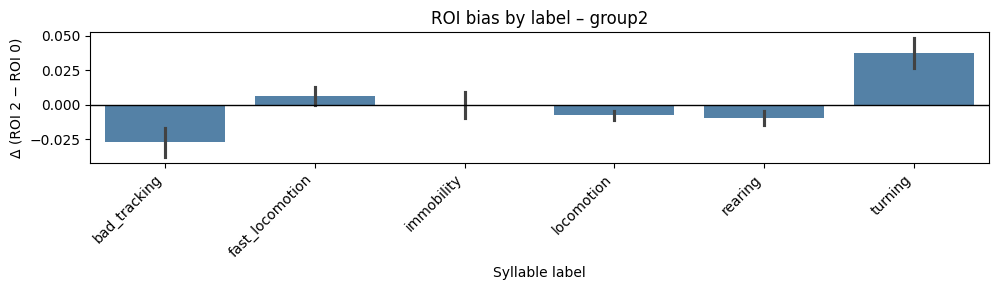

In [16]:
syll_info_path = "/Users/annateruel/Desktop/syll_info.csv"

# Start from your existing contrast_df (per syllable)
# contrast_df = compute_roi_contrast(...)

# Collapse syllables -> labels
contrast_df_label = collapse_contrast_by_label(
    contrast_df,
    syll_info_path=syll_info_path,
    var="frequency",    # or "occupancy"
    roi_a=0,
    roi_b=2,
    label_col="label",
)

# optional stable ordering
order = sorted(contrast_df_label["syllable"].unique())

# Plot
plot_delta_by_label_sem(contrast_df_label, group="group2", order=order)

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px

def plot_barplots_with_points(
    df,
    global_df,
    variables,
    out_dir,
    alpha=0.05,
    colorscale_name="Temps",
    group_col="group",
    syllable_col="syllable",
    show_points=True,
    bar_alpha=0.55,
    point_alpha=0.85,
    point_size=15,
    jitter_scale=0.03,
    capsize=2.5,
    ylim_pad_frac=0.10,
    save_ext="svg",  # "svg" or "pdf"
):
    """
    Grouped BARPLOTS (mean ± SEM) + jittered individual points for each syllable.

    df should have columns:
      - syllable_col (e.g. "syllable" or label)
      - group_col
      - variables (numeric)

    global_df is used only to place '*' over syllables with global p < alpha.
    Expected columns: variable, pval, syllable (same naming as syllable_col by default).
    """

    os.makedirs(out_dir, exist_ok=True)

    # ---- auto-detect group column if needed ----
    if group_col not in df.columns:
        if "group1" in df.columns:
            group_col = "group1"
        else:
            raise KeyError(
                f"Could not find group column '{group_col}' in df. "
                f"Available columns: {list(df.columns)}"
            )

    if syllable_col not in df.columns:
        raise KeyError(
            f"Could not find syllable column '{syllable_col}' in df. "
            f"Available columns: {list(df.columns)}"
        )

    # --- build Matplotlib colormap from Plotly ---
    plotly_colors = px.colors.get_colorscale(colorscale_name)

    def _plotly_to_mpl_colors(colorscale):
        mpl_colors = []
        for pos, col in colorscale:
            col = col.strip()
            if col.startswith("rgb"):
                inside = col[col.find("(") + 1 : col.find(")")]
                parts = [p.strip() for p in inside.split(",")]
                r, g, b = [int(p) for p in parts]
                mpl_colors.append((r / 255.0, g / 255.0, b / 255.0))
            else:
                mpl_colors.append(col)
        return mpl_colors

    mpl_colors_list = _plotly_to_mpl_colors(plotly_colors)
    cmap = mcolors.LinearSegmentedColormap.from_list(colorscale_name, mpl_colors_list, N=256)

    groups = sorted(df[group_col].dropna().unique())
    syllables = sorted(df[syllable_col].dropna().unique())

    if len(groups) == 0:
        raise ValueError("No groups found.")
    if len(syllables) == 0:
        raise ValueError("No syllables/labels found.")

    group_colors = [cmap(i) for i in np.linspace(0, 1, len(groups))]

    # --- layout: same idea as your boxplot offsets ---
    positions = np.arange(len(syllables))

    # bar width scales with number of groups (keeps things readable)
    width = min(0.8 / len(groups), 0.22)
    offsets = np.linspace(
        -0.5 * (len(groups) - 1) * width,
        0.5 * (len(groups) - 1) * width,
        len(groups),
    )

    # --- helper for SEM ---
    def _sem(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if len(x) <= 1:
            return np.nan
        return np.std(x, ddof=1) / np.sqrt(len(x))

    for var in variables:
        if var not in df.columns:
            print(f"[skip] '{var}' not in df.columns")
            continue

        fig, ax = plt.subplots(
            figsize=(max(10, len(syllables) * 0.65), 6),
            constrained_layout=True,
        )

        # ---------- bars (mean ± SEM) + dots ----------
        # Track overall y-range for nice star placement / ylim
        all_vals = df[var].replace([np.inf, -np.inf], np.nan).dropna().values
        if len(all_vals) > 0:
            y_min, y_max = float(np.min(all_vals)), float(np.max(all_vals))
            y_rng = (y_max - y_min) if y_max > y_min else 1.0
        else:
            y_min, y_max, y_rng = 0.0, 1.0, 1.0

        for gi, g in enumerate(groups):
            means = []
            sems = []
            xcenters = positions + offsets[gi]

            for syl in syllables:
                vals = df.loc[(df[group_col] == g) & (df[syllable_col] == syl), var].dropna().values
                means.append(np.mean(vals) if len(vals) else np.nan)
                sems.append(_sem(vals) if len(vals) else np.nan)

            # bars
            ax.bar(
                xcenters,
                means,
                width=width,
                yerr=sems,
                capsize=capsize,
                color=group_colors[gi],
                alpha=bar_alpha,
                edgecolor="black",
                linewidth=0.6,
                label=g,
            )

            # points
            if show_points:
                for i, syl in enumerate(syllables):
                    vals = df.loc[(df[group_col] == g) & (df[syllable_col] == syl), var].dropna().values
                    if len(vals) == 0:
                        continue
                    jitter = np.random.normal(scale=jitter_scale, size=len(vals))
                    xpts = positions[i] + offsets[gi] + jitter
                    ax.scatter(
                        xpts,
                        vals,
                        color=group_colors[gi],
                        edgecolor="black",
                        s=point_size,
                        alpha=point_alpha,
                        linewidth=0.3,
                        zorder=3,
                    )

        # ---------- add significance '*' (global effect) ----------
        # Supports global_df using column "syllable" (like your code) OR the chosen syllable_col
        sig_syls = set()
        if global_df is not None:
            if "variable" in global_df.columns and "pval" in global_df.columns:
                syl_col_in_global = syllable_col if syllable_col in global_df.columns else "syllable"
                if syl_col_in_global in global_df.columns:
                    sig_syls = set(
                        global_df[(global_df["variable"] == var) & (global_df["pval"] < alpha)][
                            syl_col_in_global
                        ].dropna().unique()
                    )

        # place star above the tallest element at that syllable (across groups)
        for syl in sig_syls:
            if syl not in syllables:
                continue
            i = syllables.index(syl)
            ymax_here = df.loc[df[syllable_col] == syl, var].dropna().max()
            if np.isfinite(ymax_here):
                ax.text(
                    positions[i],
                    ymax_here + ylim_pad_frac * y_rng,
                    "*",
                    ha="center",
                    va="bottom",
                    fontsize=18,
                    color="black",
                )

        ax.set_xticks(positions)
        ax.set_xticklabels(syllables, rotation=45, ha="right")
        ax.set_xlabel("Syllable" if syllable_col == "syllable" else syllable_col)
        ax.set_ylabel(var)
        ax.set_title(f"{var.capitalize()} by group and {syllable_col}\n('*' = global effect p < {alpha})")

        # nice y-lims
        ax.set_ylim(y_min - 0.05 * y_rng, y_max + (0.18 + ylim_pad_frac) * y_rng)

        # legend
        handles = [plt.Line2D([0], [0], color=group_colors[i], lw=6) for i in range(len(groups))]
        ax.legend(handles, groups, title="Group", loc="best")

        # vector save
        fig_path = os.path.join(out_dir, f"barplot_{var}_with_points.{save_ext}")
        fig.savefig(fig_path, dpi=300)  # dpi irrelevant for svg, fine for pdf
        plt.close(fig)
        print(f"Saved: {fig_path}")
plot_barplots_with_points(
    df=contrast_df_label,          # one row per animal x group x label
    global_df=None,           # optional: for '*' per label
    variables=["delta"],           # or ["log2_ratio"] or ["delta", "log2_ratio"]
    out_dir="/Users/annateruel/Desktop/roi_plots2",
    alpha=0.05,
    colorscale_name="Temps",
    group_col="group",
    syllable_col="syllable",
    save_ext="svg",                # or "pdf"
)




Saved: /Users/annateruel/Desktop/roi_plots2/barplot_delta_with_points.svg


Comparing ROI 0 (NA) to ROI 2 (A)

In [18]:
from scipy import stats
import statsmodels.stats.multitest as smm

def paired_roi_tests(
    contrast_df,
    var_roi0_col="occupancy_roi0",
    var_roi2_col="occupancy_roi1",
    group_col="group",
    alpha=0.05,
    correction="fdr_bh",
):
    out = []

    for (g, syl), sub in contrast_df.groupby([group_col, "syllable"]):
        x0 = sub[var_roi0_col].to_numpy()
        x2 = sub[var_roi2_col].to_numpy()

        mask = np.isfinite(x0) & np.isfinite(x2)
        x0, x2 = x0[mask], x2[mask]
        n = len(x0)

        if n < 3:
            out.append({"group": g, "syllable": syl, "n": n, "test": "insufficient", "stat": np.nan, "p": np.nan})
            continue

        # Paired test: Wilcoxon is robust for non-normal
        try:
            stat_val, p_val = stats.wilcoxon(x2, x0, alternative="two-sided")
            test = "Wilcoxon(paired)"
        except Exception:
            stat_val, p_val = np.nan, np.nan
            test = "Wilcoxon_error"

        out.append({"group": g, "syllable": syl, "n": n, "test": test, "stat": stat_val, "p": p_val})

    res = pd.DataFrame(out)

    # Multiple-comparisons correction within each group (across syllables)
    res["p_adj"] = np.nan
    res["significant"] = False

    for g, idx in res.groupby("group").groups.items():
        pvals = res.loc[idx, "p"].to_numpy()
        ok = np.isfinite(pvals)
        if ok.sum() == 0:
            continue
        reject, p_adj, _, _ = smm.multipletests(pvals[ok], alpha=alpha, method=correction)
        res.loc[idx[ok], "p_adj"] = p_adj
        res.loc[idx[ok], "significant"] = reject

    return res

# Run:
contrast_df = compute_roi_contrast(
    "/Users/annateruel/Desktop/stats_chamber/stats_df_with_roi.csv",
    roi_a=0, roi_b=2,
    var="frequency",
    group_col="group",
)
tests_df = paired_roi_tests(
    contrast_df,
    var_roi0_col="frequency_roi0",
    var_roi2_col="frequency_roi2",
    group_col="group",
    alpha=0.05,
)
print(tests_df.sort_values(["group","p_adj"]).head(20))

ROI indices present in file: [-1, 0, 1, 2]
After filtering to roi_a=0, roi_b=2: [0, 2]
Rows kept: 4371
     group  syllable   n              test  stat         p     p_adj  \
6   group1         6  13  Wilcoxon(paired)  13.0  0.021484  0.524902   
19  group1        19  11  Wilcoxon(paired)  10.0  0.041992  0.524902   
0   group1         0  16  Wilcoxon(paired)  32.0  0.111769  0.576782   
1   group1         1  16  Wilcoxon(paired)  43.0  0.211426  0.576782   
2   group1         2  10  Wilcoxon(paired)  13.0  0.160156  0.576782   
8   group1         8  20  Wilcoxon(paired)  70.0  0.202450  0.576782   
10  group1        10  14  Wilcoxon(paired)  34.0  0.267578  0.576782   
12  group1        12   9  Wilcoxon(paired)  12.0  0.250000  0.576782   
13  group1        13  19  Wilcoxon(paired)  57.0  0.133621  0.576782   
14  group1        14  19  Wilcoxon(paired)  65.0  0.241253  0.576782   
21  group1        21  15  Wilcoxon(paired)  40.0  0.276855  0.576782   
25  group1        25   3  Wilcoxo

collapsing the labels for testing

In [19]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm

def collapse_contrast_to_labels_for_tests(
    contrast_df,
    syll_info_path,
    var="occupancy",
    roi_a=0,
    roi_b=1,
    group_col="group",
    label_col="label",
    agg="sum",  # sum is usually right for occupancy/frequency across syllables in a label
):
    """
    Takes contrast_df produced by compute_roi_contrast() (one row per name x group x syllable),
    and collapses syllables into labels.

    Returns one row per name x group x label with paired ROI columns:
      - f"{var}_roi{roi_a}"
      - f"{var}_roi{roi_b}"
    plus a 'syllable' column that actually stores the label (to match your plotting/testing API).
    """
    df = contrast_df.copy()

    col_a = f"{var}_roi{roi_a}"
    col_b = f"{var}_roi{roi_b}"

    needed = {"name", group_col, "syllable", col_a, col_b}
    missing = needed - set(df.columns)
    if missing:
        raise KeyError(f"contrast_df missing columns: {missing}. Found: {list(df.columns)}")

    syll_info = pd.read_csv(syll_info_path)
    if "syllable" not in syll_info.columns or label_col not in syll_info.columns:
        raise KeyError(f"syll_info must contain columns: 'syllable' and '{label_col}'")

    # map syllable -> label
    df = df.merge(syll_info[["syllable", label_col]], on="syllable", how="left")
    df = df.dropna(subset=[label_col]).copy()

    # collapse within animal/group/label
    if agg == "sum":
        aggfunc = "sum"
    elif agg == "mean":
        aggfunc = "mean"
    else:
        raise ValueError("agg must be 'sum' or 'mean'")

    collapsed = (
        df.groupby(["name", group_col, label_col], as_index=False)
          .agg(**{
              col_a: (col_a, aggfunc),
              col_b: (col_b, aggfunc),
          })
    )

    # keep your downstream API using "syllable" as the category column
    collapsed = collapsed.rename(columns={label_col: "syllable"})

    return collapsed

def paired_roi_tests(
    contrast_df,
    var_roiA_col,
    var_roiB_col,
    group_col="group",
    alpha=0.05,
    correction="fdr_bh",
    alternative="two-sided",
    min_n=3,
):
    out = []

    for (g, cat), sub in contrast_df.groupby([group_col, "syllable"]):
        xA = sub[var_roiA_col].to_numpy()
        xB = sub[var_roiB_col].to_numpy()

        mask = np.isfinite(xA) & np.isfinite(xB)
        xA, xB = xA[mask], xB[mask]
        n = len(xA)

        if n < min_n:
            out.append({"group": g, "syllable": cat, "n": n, "test": "insufficient", "stat": np.nan, "p": np.nan})
            continue

        try:
            stat_val, p_val = stats.wilcoxon(xB, xA, alternative=alternative)
            test = "Wilcoxon(paired)"
        except Exception:
            stat_val, p_val = np.nan, np.nan
            test = "Wilcoxon_error"

        out.append({"group": g, "syllable": cat, "n": n, "test": test, "stat": stat_val, "p": p_val})

    res = pd.DataFrame(out)

    # FDR within each group (across labels)
    res["p_adj"] = np.nan
    res["significant"] = False

    for g in res["group"].dropna().unique():
        sub_idx = res.index[res["group"] == g]
        pvals = res.loc[sub_idx, "p"].to_numpy()
        ok = np.isfinite(pvals)

        if ok.sum() == 0:
            continue

        reject, p_adj, _, _ = smm.multipletests(pvals[ok], alpha=alpha, method=correction)

        # assign back only where ok
        ok_idx = sub_idx[ok]
        res.loc[ok_idx, "p_adj"] = p_adj
        res.loc[ok_idx, "significant"] = reject

    return res


# 1) per-syllable paired table
contrast_df = compute_roi_contrast(
    "/Users/annateruel/Desktop/stats_chamber/stats_df_with_roi.csv",
    roi_a=0, roi_b=2,
    var="frequency",
    group_col="group",
)

# 2) collapse syllables -> labels (reduces #comparisons)
contrast_df_label_tests = collapse_contrast_to_labels_for_tests(
    contrast_df,
    syll_info_path="/Users/annateruel/Desktop/syll_info.csv",
    var="frequency",
    roi_a=0,
    roi_b=2,
    group_col="group",
    label_col="label",
    agg="sum",
)

# 3) paired Wilcoxon per group x label with FDR within group
tests_label_df = paired_roi_tests(
    contrast_df_label_tests,
    var_roiA_col="frequency_roi0",
    var_roiB_col="frequency_roi2",
    group_col="group",
    alpha=0.05,
    correction="fdr_bh",
)

print(tests_label_df.sort_values(["group", "p_adj"]).head(30))

ROI indices present in file: [-1, 0, 1, 2]
After filtering to roi_a=0, roi_b=2: [0, 2]
Rows kept: 4371
     group         syllable   n              test    stat         p     p_adj  \
3   group1       locomotion  24  Wilcoxon(paired)    82.0  0.052641  0.315845   
0   group1     bad_tracking  25  Wilcoxon(paired)   106.0  0.133640  0.400920   
1   group1  fast_locomotion  26  Wilcoxon(paired)   148.0  0.499195  0.515301   
2   group1       immobility  26  Wilcoxon(paired)   149.0  0.515301  0.515301   
4   group1          rearing  25  Wilcoxon(paired)   123.0  0.299612  0.515301   
5   group1          turning  26  Wilcoxon(paired)   140.0  0.380194  0.515301   
11  group2          turning  75  Wilcoxon(paired)   849.0  0.002353  0.014119   
6   group2     bad_tracking  73  Wilcoxon(paired)   913.0  0.016164  0.037877   
9   group2       locomotion  69  Wilcoxon(paired)   815.0  0.018938  0.037877   
10  group2          rearing  74  Wilcoxon(paired)  1114.0  0.140640  0.210960   
7   gr

cleaner code!!!! perhaps use this instead! 

In [28]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm


def _clean_str_series(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    s = s.str.replace(r"[\r\n\t]", "", regex=True).str.strip()
    return s


def _force_non_categorical(df: pd.DataFrame, cols):
    """Make sure cols are NOT categorical (prevents unobserved cartesian expansion)."""
    for c in cols:
        if c in df.columns and pd.api.types.is_categorical_dtype(df[c]):
            df[c] = df[c].astype("string")
        else:
            # also normalize to string dtype for safety/consistency
            df[c] = df[c].astype("string")
    return df


def build_label_delta_table(
    csv_path,
    syll_info_path,
    var="occupancy",
    roi_a=0,
    roi_b=2,
    group_col="group",
    label_col="label",
    agg="sum",
    drop_unlabeled=True,
    fill_missing_rois_with_zero=True,
    verbose=True,
):
    df = pd.read_csv(csv_path)

    needed = {"name", group_col, "roi_index", "syllable", var}
    missing = needed - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns in data: {missing}. Found: {list(df.columns)}")

    # clean strings early
    df["name"] = _clean_str_series(df["name"])
    df[group_col] = _clean_str_series(df[group_col])

    df["roi_index"] = pd.to_numeric(df["roi_index"], errors="coerce").astype("Int64")

    if verbose:
        print("\n=== RAW ===")
        print("RAW rows:", len(df))
        print("RAW animals:", df["name"].nunique(dropna=True))
        print("RAW rois:", sorted(df["roi_index"].dropna().unique().tolist()))
        print("RAW syllables:", df["syllable"].nunique(dropna=True))
        print("RAW dtypes:", {k: str(df[k].dtype) for k in ["name", group_col]})

    # keep only ROIs of interest
    df = df[df["roi_index"].isin([roi_a, roi_b])].copy()

    if verbose:
        print("\n=== After ROI filter ===")
        print("Rows kept:", len(df))
        print("ROIs kept:", sorted(df["roi_index"].dropna().unique().tolist()))
        print("Animals per group (raw, after ROI filter):")
        print(df.groupby(group_col)["name"].nunique())

    # map syllable -> label
    syll_info = pd.read_csv(syll_info_path)
    if "syllable" not in syll_info.columns or label_col not in syll_info.columns:
        raise KeyError(f"syll_info must contain 'syllable' and '{label_col}' columns")

    df = df.merge(syll_info[["syllable", label_col]], on="syllable", how="left")

    if drop_unlabeled:
        before = len(df)
        df = df.dropna(subset=[label_col]).copy()
        if verbose:
            print("\n=== After label merge + drop_unlabeled ===")
            print("Dropped unlabeled rows:", before - len(df))
            print("Rows kept:", len(df))
            print("Unique labels:", df[label_col].nunique(dropna=True))

    # IMPORTANT: ensure keys are not categorical
    df = _force_non_categorical(df, ["name", group_col, label_col])

    # sanity: each animal must belong to one group in raw
    ngrp_raw = df.groupby("name", observed=True)[group_col].nunique()
    if (ngrp_raw > 1).any():
        bad_names = ngrp_raw[ngrp_raw > 1].index.tolist()
        print("\n[ERROR] RAW has names in multiple groups. Examples:")
        for nm in bad_names[:10]:
            vals = df.loc[df["name"] == nm, group_col].unique().tolist()
            print(" -", nm, "->", vals)
        raise ValueError("Some animals appear in multiple groups in RAW (after cleaning).")

    if agg not in {"sum", "mean"}:
        raise ValueError("agg must be 'sum' or 'mean'")

    # aggregate within animal/group/ROI/label
    agg_df = (
        df.groupby(["name", group_col, "roi_index", label_col], as_index=False, observed=True)[var]
          .agg(agg)
    )

    # ensure agg_df keys not categorical too
    agg_df = _force_non_categorical(agg_df, ["name", group_col, label_col])

    if verbose:
        print("\n=== agg_df (BEFORE pivot) ===")
        print("agg_df rows:", len(agg_df))
        print("agg_df animals:", agg_df["name"].nunique(dropna=True))
        print("animals per ROI (overall):")
        print(agg_df.groupby("roi_index", observed=True)["name"].nunique())
        print("agg_df dtypes:", {k: str(agg_df[k].dtype) for k in ["name", group_col, label_col]})

    # pivot ROIs to columns
    wide = agg_df.pivot_table(
        index=["name", group_col, label_col],
        columns="roi_index",
        values=var,
        aggfunc="mean",
        observed=True,   # <-- THIS IS THE KEY FIX
        dropna=True,
    ).reset_index()

    col_a = f"{var}_roi{roi_a}"
    col_b = f"{var}_roi{roi_b}"

    if roi_a not in wide.columns:
        wide[roi_a] = np.nan
    if roi_b not in wide.columns:
        wide[roi_b] = np.nan

    wide = wide.rename(columns={roi_a: col_a, roi_b: col_b, label_col: "label"})

    # sanity after pivot: names must still be in one group
    ngrp_wide = wide.groupby("name", observed=True)[group_col].nunique()
    if (ngrp_wide > 1).any():
        bad_names = ngrp_wide[ngrp_wide > 1].index.tolist()
        print("\n[ERROR] wide has names in multiple groups AFTER pivot. Examples:")
        for nm in bad_names[:10]:
            vals = wide.loc[wide["name"] == nm, group_col].unique().tolist()
            print(" -", nm, "->", vals)
        raise ValueError("Pivot produced multi-group names (should be fixed by observed=True).")

    if fill_missing_rois_with_zero:
        wide[[col_a, col_b]] = wide[[col_a, col_b]].fillna(0)

    wide["delta"] = wide[col_b] - wide[col_a]

    if verbose:
        print("\n=== wide (AFTER pivot) ===")
        print("wide rows:", len(wide))
        print("NaNs:", col_a, wide[col_a].isna().sum(), "|", col_b, wide[col_b].isna().sum(), "| delta", wide["delta"].isna().sum())

        print("\n=== Sample-size checks ===")
        print("Animals per group (raw):")
        print(df.groupby(group_col, observed=True)["name"].nunique())
        print("Animals per group (wide):")
        print(wide.groupby(group_col, observed=True)["name"].nunique())

    return wide


def test_delta_by_group_label(
    delta_df,
    group_col="group",
    label_col="label",
    alpha=0.05,
    correction="fdr_bh",
    test="ttest",
    alternative="two-sided",
    min_n=3,
    verbose=True,
):
    out = []
    for (g, lab), sub in delta_df.groupby([group_col, label_col], observed=True):
        d = sub["delta"].to_numpy()
        n_total = len(d)
        d = d[np.isfinite(d)]
        n_used = len(d)

        if n_used < min_n:
            out.append({"group": g, "label": lab, "n_total": n_total, "n_used": n_used,
                        "test": "insufficient", "stat": np.nan, "p": np.nan})
            continue

        if test == "ttest":
            stat_val, p_val = stats.ttest_1samp(d, popmean=0.0, alternative=alternative)
            test_name = "t-test(1-sample)"
        elif test == "wilcoxon":
            stat_val, p_val = stats.wilcoxon(d, alternative=alternative)
            test_name = "Wilcoxon(1-sample on Δ)"
        else:
            raise ValueError("test must be 'ttest' or 'wilcoxon'")

        out.append({"group": g, "label": lab, "n_total": n_total, "n_used": n_used,
                    "test": test_name, "stat": stat_val, "p": p_val,
                    "delta_median": float(np.median(d)), "delta_mean": float(np.mean(d))})

    res = pd.DataFrame(out)
    res["p_adj"] = np.nan
    res["significant"] = False

    for g in res["group"].dropna().unique():
        idx = res.index[res["group"] == g]
        pvals = res.loc[idx, "p"].to_numpy()
        ok = np.isfinite(pvals)
        if ok.sum() == 0:
            continue
        reject, p_adj, _, _ = smm.multipletests(pvals[ok], alpha=alpha, method=correction)
        res.loc[idx[ok], "p_adj"] = p_adj
        res.loc[idx[ok], "significant"] = reject

    if verbose:
        print("\n=== n_total vs n_used (should match) ===")
        print(res[["group", "label", "n_total", "n_used"]].sort_values(["group", "label"]))

    return res


# ---- RUN ----
delta_df = build_label_delta_table(
    csv_path="/Users/annateruel/Desktop/stats_chamber/stats_df_with_roi.csv",
    syll_info_path="/Users/annateruel/Desktop/syll_info.csv",
    var="frequency",
    roi_a=0,
    roi_b=2,
    group_col="group",
    label_col="label",
    agg="sum",
    fill_missing_rois_with_zero=True,
    verbose=True,
)

res = test_delta_by_group_label(
    delta_df,
    group_col="group",
    label_col="label",
    test="ttest",
    correction="fdr_bh",
    alpha=0.05,
    alternative="two-sided",
    verbose=True,
)

print(res.sort_values(["group", "p_adj"]))


=== RAW ===
RAW rows: 5840
RAW animals: 148
RAW rois: [-1, 0, 1, 2]
RAW syllables: 26
RAW dtypes: {'name': 'string', 'group': 'string'}

=== After ROI filter ===
Rows kept: 4371
ROIs kept: [0, 2]
Animals per group (raw, after ROI filter):
group
group1    26
group2    75
group3    24
group4    23
Name: name, dtype: int64

=== After label merge + drop_unlabeled ===
Dropped unlabeled rows: 0
Rows kept: 4371
Unique labels: 6

=== agg_df (BEFORE pivot) ===
agg_df rows: 1639
agg_df animals: 148
animals per ROI (overall):
roi_index
0    148
2    148
Name: name, dtype: int64
agg_df dtypes: {'name': 'string', 'group': 'string', 'label': 'string'}

=== wide (AFTER pivot) ===
wide rows: 869
NaNs: frequency_roi0 0 | frequency_roi2 0 | delta 0

=== Sample-size checks ===
Animals per group (raw):
group
group1    26
group2    75
group3    24
group4    23
Name: name, dtype: int64
Animals per group (wide):
group
group1    26
group2    75
group3    24
group4    23
Name: name, dtype: int64

=== n_total 

/var/folders/q4/d9bmvghd77x_l961kcngf8_c0000gn/T/ipykernel_19566/2948875614.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if c in df.columns and pd.api.types.is_categorical_dtype(df[c]):
/var/folders/q4/d9bmvghd77x_l961kcngf8_c0000gn/T/ipykernel_19566/2948875614.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if c in df.columns and pd.api.types.is_categorical_dtype(df[c]):
/var/folders/q4/d9bmvghd77x_l961kcngf8_c0000gn/T/ipykernel_19566/2948875614.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if c in df.columns and pd.api.types.is_categorical_dtype(df[c]):
/var/folders/q4/d9bmvghd77x_l961kcngf8_c0000gn/T/ipykernel_19566/2948875614.py:16: DeprecationWarning: is_cat

LMM 

$\textbf{occupancy} \sim \textbf{ROI} * \textbf{syllable} + (1|\textbf{animal})$

In [29]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf


def build_lmm_dataframe(
    csv_path,
    syll_info_path,
    var="occupancy",
    roi_keep=(0, 1),
    group_col="group",
    label_col="label",
    agg="sum",
):
    df = pd.read_csv(csv_path)

    # clean strings
    df["name"] = df["name"].astype("string").str.strip()
    df[group_col] = df[group_col].astype("string").str.strip()

    df["roi_index"] = pd.to_numeric(df["roi_index"], errors="coerce")

    # keep only desired ROIs
    df = df[df["roi_index"].isin(roi_keep)].copy()

    # merge label
    syll_info = pd.read_csv(syll_info_path)
    df = df.merge(syll_info[["syllable", label_col]], on="syllable", how="left")

    # aggregate per animal × ROI × label
    agg_df = (
        df.groupby(["name", group_col, "roi_index", label_col], observed=True)[var]
          .agg(agg)
          .reset_index()
    )

    # convert to categorical for modeling
    agg_df["ROI"] = agg_df["roi_index"].astype("category")
    agg_df["syllable"] = agg_df[label_col].astype("category")
    agg_df["animal"] = agg_df["name"].astype("category")

    return agg_df
def fit_lmm_roi_syllable(lmm_df):
    model = smf.mixedlm(
        "occupancy ~ ROI * syllable",
        data=lmm_df,
        groups=lmm_df["animal"],  # random intercept per animal
    )
    result = model.fit(reml=True)
    return result

lmm_df = build_lmm_dataframe(
    csv_path="/Users/annateruel/Desktop/stats_cups/stats_df_with_roi.csv",
    syll_info_path="/Users/annateruel/Desktop/syll_info.csv",
    var="occupancy",
    roi_keep=(0, 1),
)

res = fit_lmm_roi_syllable(lmm_df)

print(res.summary())


/Users/annateruel/miniconda3/envs/kpms/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/annateruel/miniconda3/envs/kpms/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                     Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         occupancy
No. Observations:         1522            Method:                     REML     
No. Groups:               148             Scale:                      0.0105   
Min. group size:          5               Log-Likelihood:             1270.5657
Max. group size:          12              Converged:                  Yes      
Mean group size:          10.3                                                 
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             0.076    0.009  8.468 0.000  0.058  0.094
ROI[T.1]                              0.000    0.013  0.022 0.982 -0.026  0.026
syllable[T.fast_locomotion]           0.015    0.012  1.230 0

/Users/annateruel/miniconda3/envs/kpms/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/annateruel/miniconda3/envs/kpms/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
